# Лабораторная работа №1

## Загрузка и подготовка данных

Импорт необходимых библиотек для этого этапа.

In [148]:
import pandas as pd
import numpy as np

Чтение датасета.

In [149]:
df = pd.read_csv("data/student_lifestyle_100k.csv")

Посмотрим заголовок таблицы и первые строки.

In [150]:
df.head()

,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Посмотрим информацию о data frame.

In [151]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Student_ID          100000 non-null  int64  
 1   Age                 100000 non-null  int64  
 2   Gender              100000 non-null  str    
 3   Department          100000 non-null  str    
 4   CGPA                100000 non-null  float64
 5   Sleep_Duration      100000 non-null  float64
 6   Study_Hours         100000 non-null  float64
 7   Social_Media_Hours  100000 non-null  float64
 8   Physical_Activity   100000 non-null  int64  
 9   Stress_Level        100000 non-null  int64  
 10  Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(4), str(2)
memory usage: 7.7 MB


Проверим на дубликаты и на количество пропущенных значений.

In [152]:
df.duplicated().sum()

np.int64(0)

Видим: в df нет дубликатов. Никаких дейтсвий по их очистке делать не требуется. Запомним этот факт.

Теперь проверим на количество пропусков в каждой колонке.

In [153]:
df.isna().sum()  # axis = 0 => сумма по столбцам

Student_ID            0
Age                   0
Gender                0
Department            0
CGPA                  0
Sleep_Duration        0
Study_Hours           0
Social_Media_Hours    0
Physical_Activity     0
Stress_Level          0
Depression            0
dtype: int64

Видим: в df нет ни одного пропуска во всех колонках. Запомним этот факт, и далее опустим все проверки на пропуски.

Удалим неинтересующую нас колонку 'Student_ID', а остальные для удобства переименуем. 

In [154]:
df = df.drop(["Student_ID"], axis=1)

df = df.rename(
    columns={
        "Department": "Profile",
        "Sleep_Duration": "Sleep",
        "Study_Hours": "Study",
        "Social_Media_Hours": "Media",
        "Physical_Activity": "Sport",
        "Stress_Level": "Stress",
    }
)

Также заметим: значения в новой колонке 'Spor' приведены как минуты в неделю. Для удобства оанализа преобразуем их к часы в день. Тогда колонки 'Sport', 'Media', 'Sleep', 'Study' будут иметь одинаковые единицы измерения.

In [155]:
df["Sport"] = df["Sport"] / (60 * 7)

In [156]:
df.head()

,Age,Gender,Profile,CGPA,Sleep,Study,Media,Sport,Stress,Depression
0,22,Female,Science,3.50,7.3,3.3,3.4,0.271429,5,False
1,20,Male,Engineering,2.72,5.5,7.2,6.0,0.338095,2,False
2,20,Male,Medical,3.01,5.4,2.3,1.8,0.326190,3,False
3,21,Male,Engineering,3.63,8.1,2.0,4.6,0.309524,3,False
4,19,Male,Arts,3.14,6.8,2.6,4.3,0.009524,6,False


Теперь проверим, что в данных нет логических ошибок. Для удобства вставлю исходное описание:
| Название столбца         | Описание                                                        | Тип данных          |
|--------------------------|-----------------------------------------------------------------|---------------------|
| Age                      | Возраст студента (18-24)                                        | Целое число         |
| Gender                   | Пол студента (мужской/женский)                                  | Строка              |
| Department               | Область обучения (инженерное дело, бизнес, искусство и т. д.)    | Строка              |
| CGPA                     | Средний балл успеваемости (0.0 - 4.0)                           | Число с плавающей запятой |
| Sleep_Duration           | Среднее количество часов сна в сутки                            | Число с плавающей запятой |
| Study_Hours              | Среднее количество часов, затраченных на учебу в день           | Число с плавающей запятой |
| Social_Media_Hours       | Среднее количество часов, проведённых в социальных сетях в день | Число с плавающей запятой |
| Physical_Activity        | Среднее количество минут физической активности в неделю         | Целое число         |
| Stress_Level             | Уровень стресса, по самооценке (шкала 0-10)                     | Целое число         |
| Depression               | Состояние психического здоровья (True = Вероятная депрессия, False = Здоровый) | Логическое значение |

In [157]:
# Все значения в полях колонок отражающих время - неотрицательные
negative_rows = (
    (df["Study"] < 0) | (df["Sleep"] < 0) | (df["Media"] < 0) | (df["Sport"] < 0)
)

print("Строк с отрицательным временем нет: ", negative_rows.sum() == 0)

# Проверим что нету строк со значениями по времени > 15ч
extrime_rows = (
    (df["Study"] > 15) | (df["Sleep"] > 15) | (df["Media"] > 15) | (df["Sport"] > 15)
)

print("Строк с экстримальм временем (> 15ч) нет: ", extrime_rows.sum() == 0)

# Проверим, что в колонке со значем пол только 2 значения
unique_gender = df["Gender"].unique()
print("Пол только м. и ж.: ", len(unique_gender) == 2)

# Проверим, что 0 < CGPA < 4
row_error_cgpa = (df["CGPA"] < 0) | (df["CGPA"] > 4)
print("Значения CGPA лежат в [0, 4]: ", row_error_cgpa.sum() == 0)

# Проверим, что возраст студентов лежит в [18, 24]
row_error_age = (df["Age"] < 18) | (df["Age"] > 24)
print("Возраст студентов лежит в [18, 24]: ", row_error_cgpa.sum() == 0)

# Проверим, сколько будет сумма часов указанных в сутки для каждого студенка
sum_hours_per_day = df["Sleep"] + df["Study"] + df["Media"] + df["Sport"]
hours_unknown = np.zeros(len(sum_hours_per_day), dtype=float) * 24 - sum_hours_per_day

print("Min указанные часы в день: ", min(sum_hours_per_day))
print("Max указанные часы в день: ", max(sum_hours_per_day))

extreme_sum_hours_per_day = sum_hours_per_day > 24
print(
    "Количество студентов с сумой времени > 24ч в день:",
    extreme_sum_hours_per_day.sum(),
)
# Тут есть значение > 27ч, нижи попробую предположить почему это могло произойти

# Проверим, что уровень стресса лежит в [0, 10]
row_error_stress = (df["Stress"] < 0) | (df["Stress"] > 10)
print("Ошибок в колонке Stress нет: ", row_error_stress.sum() == 0)

Строк с отрицательным временем нет:  True
Строк с экстримальм временем (> 15ч) нет:  True
Пол только м. и ж.:  True
Значения CGPA лежат в [0, 4]:  True
Возраст студентов лежит в [18, 24]:  True
Min указанные часы в день:  3.6
Max указанные часы в день:  27.361904761904764
Количество студентов с сумой времени > 24ч в день: 109
Ошибок в колонке Stress нет:  True


Я обнаружил, что у ряда студентов сумма активностей превышает 24 часа (max = 27.36). Я решил оставить эти данные, предполагая возможность совмещения активностей (например, прослушивание аудиокниг во время занятий спортом), так как отклонение не является критическим (менее 15% от 24 часов), но стоить иметь ввиду этот факт. Я не буду считать это ошибкой, и не буду заменять время или же удалять эти строки.

## Разведочный анализ даннх (EDA)

Импортируем дополнительно библиотеки для этого этапа.

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

Создам копию data frame, чтобы не влиять на исходные данные во время EDA.

In [159]:
eda_df = df.copy()

### Анализ целевых переемнныхпеременных

Гистрограмма для CGPA:

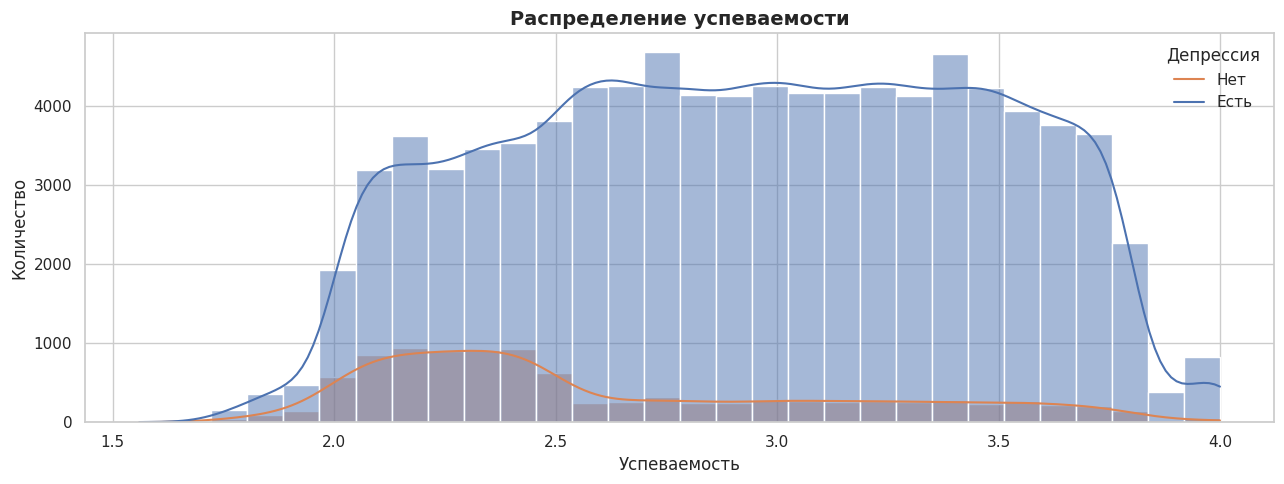

In [160]:
plt.figure(figsize=(13, 5))

sns.histplot(data=eda_df, x="CGPA", kde=True, bins=30, hue="Depression")

plt.xlabel("Успеваемость")
plt.ylabel("Количество")
plt.title("Распределение успеваемости", fontsize=14, fontweight="bold")
plt.legend(title="Депрессия", labels=["Нет", "Есть"])

plt.tight_layout()
plt.show()

Видим, что распределение по успеваемости имеет форму трапеции, с длинным платом, сильных перекосов не видно. Причём, видно, что люди с депрессией чаще имеют более низкую успеваемость и людей с депрессией сильно меньше чем людей без неё, но это первичный анализ. Более подробно это рассмотрим на следующих графиках.

Countplot для Depression:

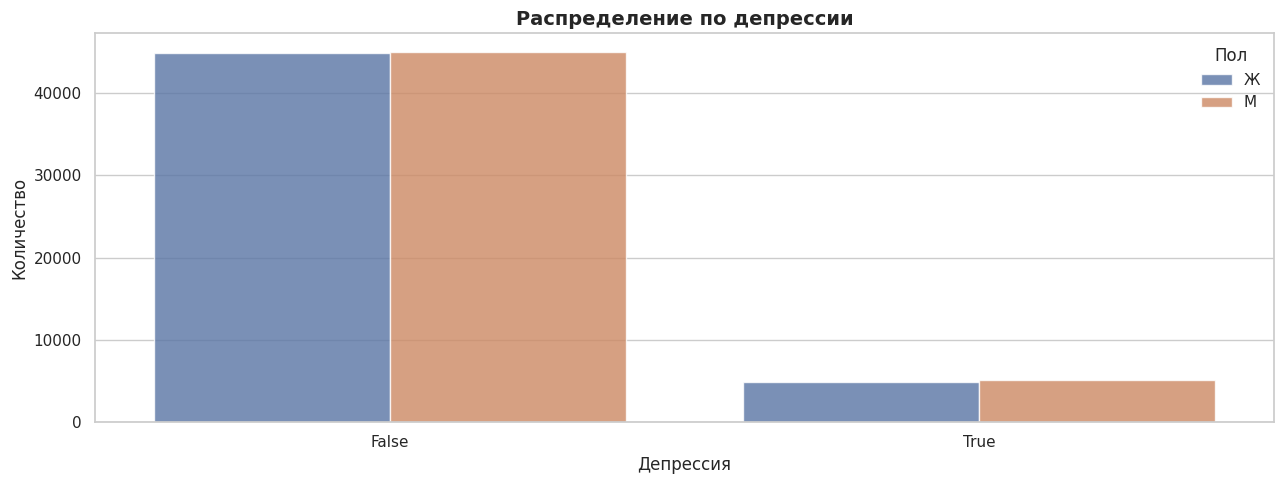

Людей без депрессии: 89938 (89.938%)
Людей с депрессией: 10062 (10.062%)


In [161]:
plt.figure(figsize=(13, 5))

sns.countplot(data=eda_df, x="Depression", hue="Gender", alpha=0.8)

plt.xlabel("Депрессия")
plt.ylabel("Количество")
plt.title("Распределение по депрессии", fontsize=14, fontweight="bold")
plt.legend(title="Пол", labels=["Ж", "М"])

plt.tight_layout()
plt.show()

has_depression = sum(eda_df["Depression"])
has_not_deperssion = len(eda_df[["Depression"]]) - has_depression

depression_persent = 100 * has_depression / len(eda_df[["Depression"]])
not_depression_persent = 100 - depression_persent

print(f"Людей без депрессии: {has_not_deperssion} ({not_depression_persent}%)")
print(f"Людей с депрессией: {has_depression} ({depression_persent}%)")

Наблюдаем, что людей с депрессией сильно меньше чем людей без ней, при этом не видно зависимости от пола. Людей с депрессией примерно 10%, людей без неё примерно 90%. Это означает дисбаланс классов.

### Анализ признаков

#### Анализ числовых признаков

In [162]:
def plot_numeric_feat(series: pd.Series):
    """Функция для построения графиков для числовых признаков."""
    col = series.name

    # Расчёт выбросов
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers_low = (series < lower_bound).sum()
    outliers_up = (series > upper_bound).sum()

    outlier_text = (
        f"Нижняя граница выбросов: {lower_bound:.2f} ({outliers_low} шт.)\n"
        if outliers_low
        else f"Верхняя граница выбросов: {upper_bound:.2f} ({outliers_up} шт.)"
        if outliers_up
        else ""
    )

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Гистограма
    sns.histplot(data=df, x=series, bins=30, kde=True, ax=axes[0])
    axes[0].margins(y=0.25)
    axes[0].set_title(f"Распределение: {col}", fontsize=14, fontweight="bold")
    axes[0].legend(labels=["Плотность распределения"], loc="upper left")

    # Статистика
    stats_text = (
        f"Медиана: {series.median():.2f}\n"
        f"Среднее: {series.mean():.2f}\n"
        f"Диапазон: {series.min():.2f} - {series.max():.2f}"
    )

    axes[0].text(
        0.95,
        0.95,
        stats_text,
        transform=axes[0].transAxes,
        fontsize=11,
        va="top",
        ha="right",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.7),
        ma="left",
    )

    # Boxplot
    sns.boxplot(data=df, x=series, ax=axes[1], color="lightgreen", width=0.4)
    axes[1].margins(y=0.25)
    axes[1].set_title(
        f"Boxplot и Выбросы: {col}", fontsize=13, fontweight="bold", pad=15
    )

    # Статистика на Boxplot
    axes[1].text(
        0.05,
        0.95,
        outlier_text,
        transform=axes[1].transAxes,
        fontsize=11,
        va="top",
        ha="left",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.7),
        ma="left",
    )

    plt.tight_layout()
    plt.show()

In [163]:
# Выбираем числовые признаки
numeric_cols = df.select_dtypes(include="number").columns.to_list()
numeric_cols.remove("CGPA")

print(numeric_cols)

['Age', 'Sleep', 'Study', 'Media', 'Sport', 'Stress']


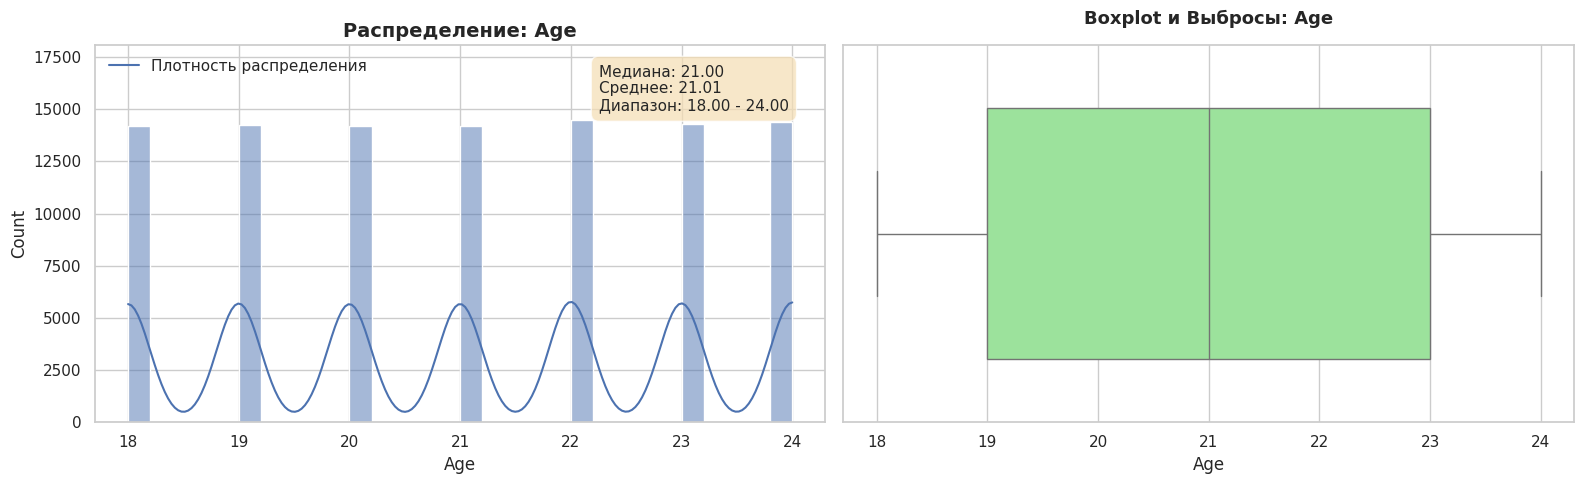

In [164]:
plot_numeric_feat(eda_df["Age"])

Дискретное равномерное разбиение по возрасту от 18 до 24 лет. Выбросы отсутствуют.

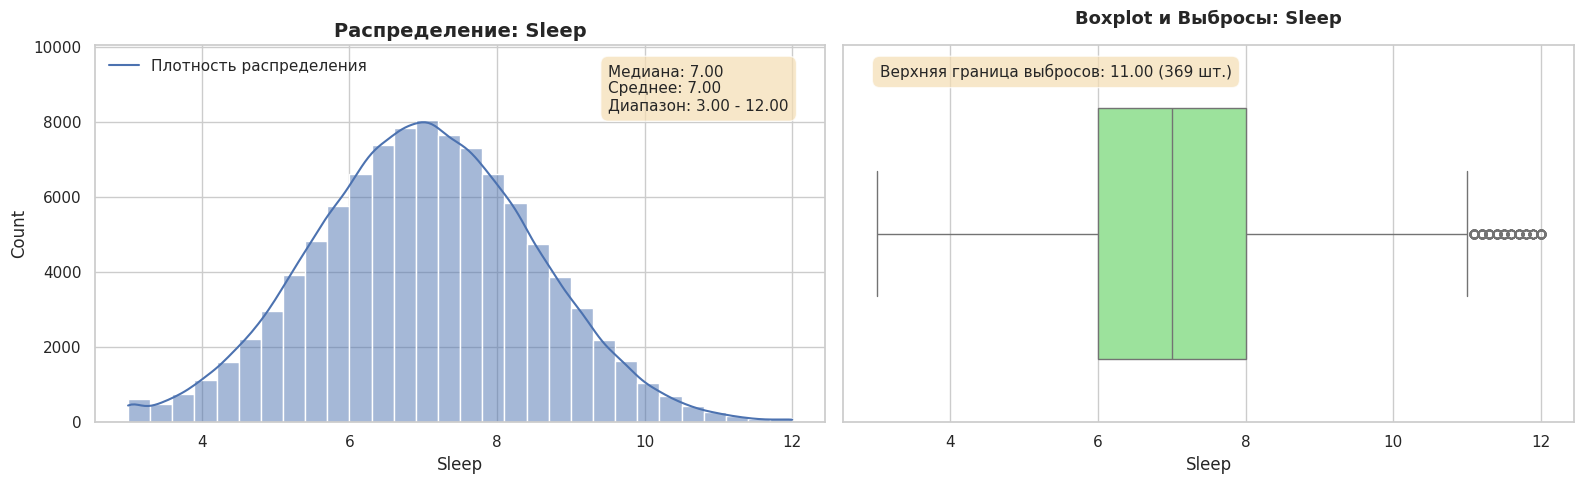

In [165]:
plot_numeric_feat(eda_df["Sleep"])

Распределение нормальное симметричное. Среднее и медиана совпадают. Сильных перекосов нет. Обнаружено 369 выбросов с значениями более 11.0 часов.

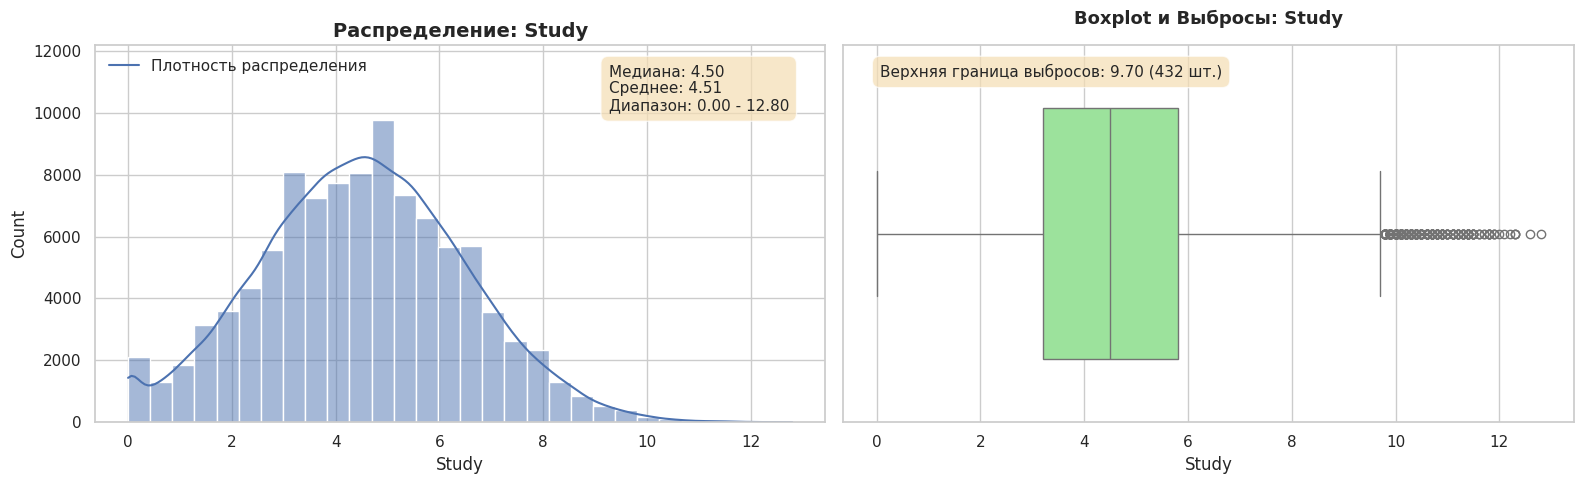

In [166]:
plot_numeric_feat(eda_df["Study"])

В распределении есть перекос в левую сторону. Обнаружено 432 выброса с значениями более 9.7 часов.

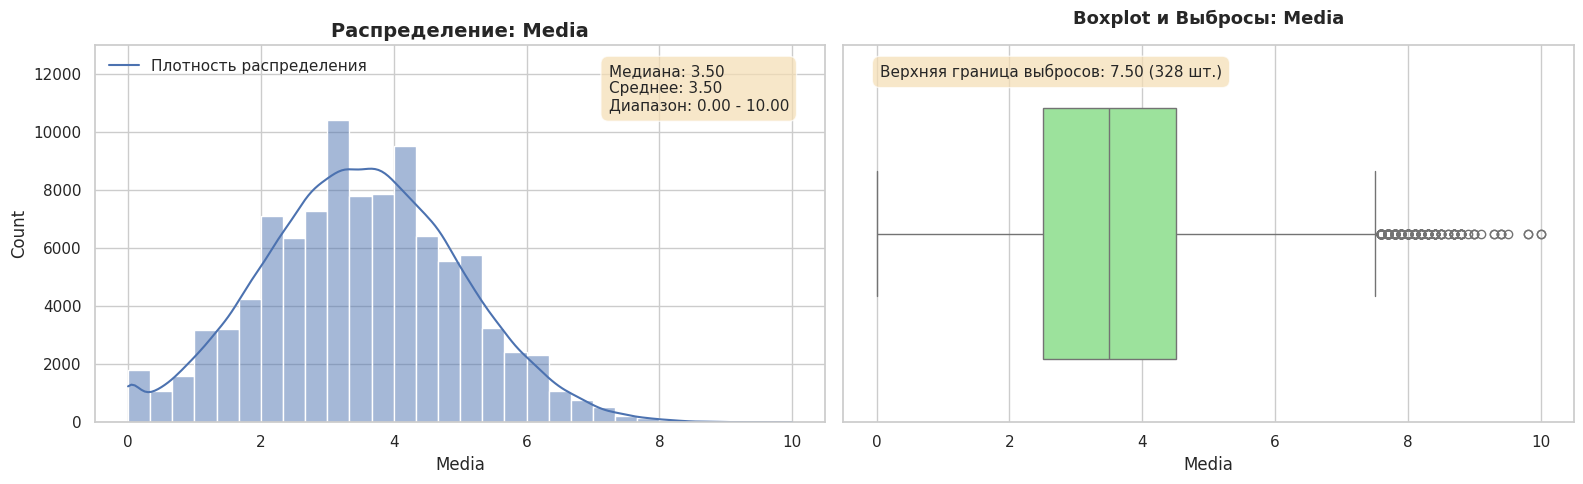

In [167]:
plot_numeric_feat(eda_df["Media"])

В распределении есть перекос в левую сторону, имеет несколько пиков. Обнаружено 328 выбросов с значениями более 7.5 часов.

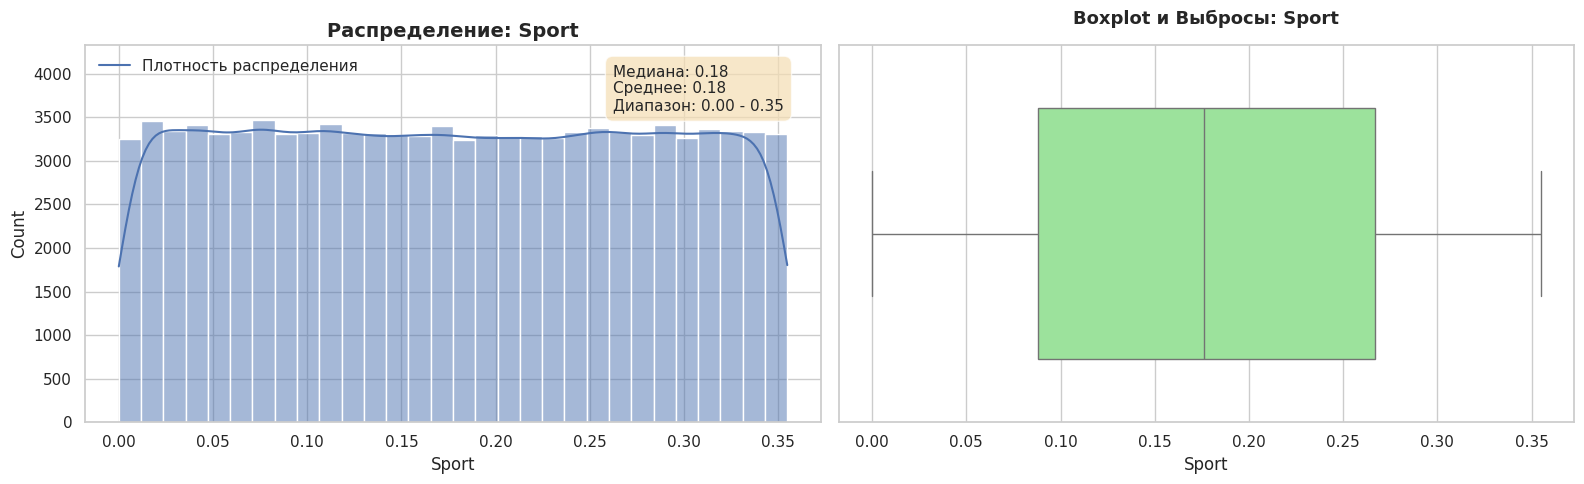

In [168]:
plot_numeric_feat(eda_df["Sport"])

Распределение равномерное. Разброс значений от 0 до 0.35. Выбросов не обнаружено

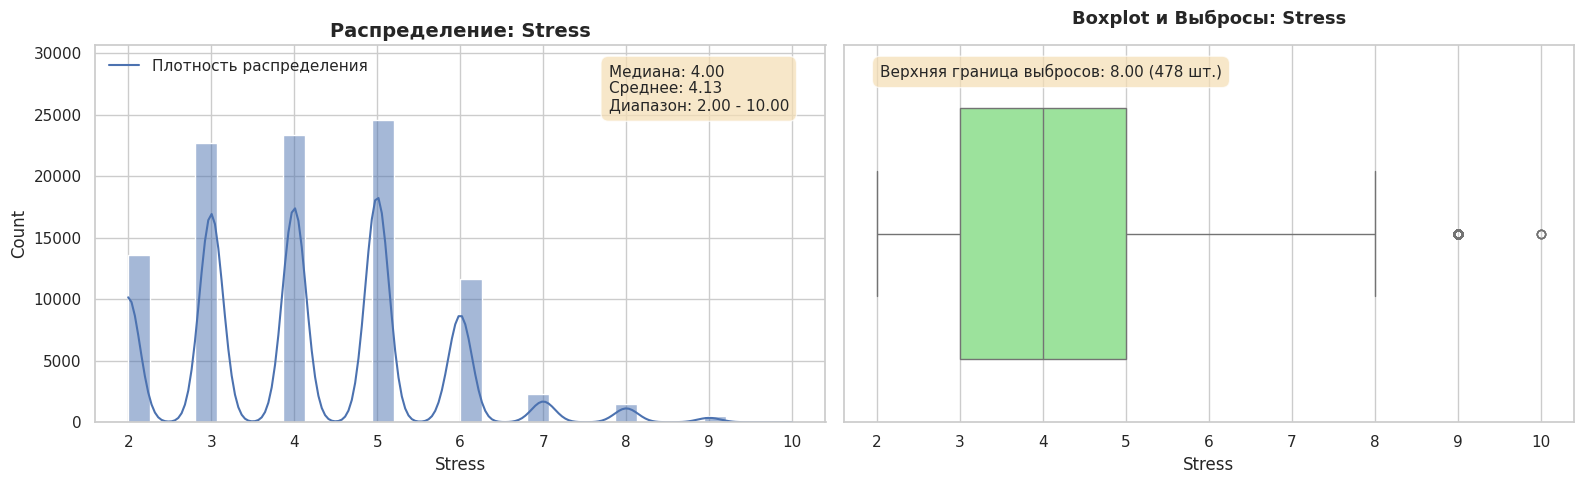

In [169]:
plot_numeric_feat(eda_df["Stress"])

Дискретное распределение c пиками в несколльких значених. Большинство оцениваю стресс как 3 - 5. Обнаружено 478 выбросов с значениями > 8.

#### Выводы по числовым признакам

Количество выбросов в признаках `Sleep`, `Study` и `Media` составляют 300 - 400 случаев из 100000. Это ≈ 0.5% от всей выборки, причем эти все выбросы - правосторонние. Принято решение выполнить коррекцию выбросов - провести винзоризацию на основе межквартильного размаха, т.е. привести все значению к отрезку $[Q1−1.5IQ; Q3+1.5IQR]$.


#### Анализ категориальных признаков

In [170]:
# Выбираем категориальные признаки
cat_cols = eda_df.select_dtypes(
    include=["object", "category", "bool", "string"]
).columns.tolist()
cat_cols.remove("Depression")

# Приводим тип
eda_df[cat_cols] = eda_df[cat_cols].astype("category")

print(cat_cols)

['Gender', 'Profile']


Несмотря на малое количество уникальных значений в признаках `Age` и `Stress`, было решено оставить их числовыми, поскольку эти признаки имеют порядок. Для выбранных `Gender` и `Profile` номинальных  категориальных признаков примененю прямое кодирование `One-Hot Encoding`.

In [171]:
def plot_cat_feat(series: pd.Series):
    """Анализирует распределение категориального признака."""
    feature_name = series.name
    value_counts = series.value_counts()
    total_count = len(series)
    unique_count = len(value_counts)

    # Barplot
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    bars = axes[0].barh(value_counts.index[::-1], value_counts[::-1], alpha=0.8)
    axes[0].set_title(f"Частоты: {feature_name}", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Количество")
    axes[0].set_ylabel("Категория")

    # Подписываем значения на столбцах (если их не слишком много)
    if len(value_counts) <= 10:
        for bar in bars:
            width = bar.get_width()
            axes[0].text(
                width + max(value_counts.values) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{int(width)}",
                va="center",
                fontsize=10,
                alpha=0.8,
            )

    # Круговая диаграмма с процентами (поскольку категорий мало, это будет нормально выглядеть)
    colors = sns.color_palette("pastel", len(value_counts))
    axes[1].pie(
        value_counts.values,
        labels=value_counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=colors,
        textprops={"fontsize": 10},
        wedgeprops={"edgecolor": "white", "linewidth": 2},  # Окантовка
    )
    axes[1].set_title(f"Доли: {feature_name}", fontsize=14, fontweight="bold")

    # Статистика на графике
    stats_text = (
        f"Категорий: {unique_count}\n"
        f"Топ: {value_counts.index[0]} ({value_counts.values[0] / total_count * 100:.1f}%)"
    )

    axes[1].text(
        -0.15,
        0.15,
        stats_text,
        transform=axes[1].transAxes,
        fontsize=10,
        ha="left",
        va="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

    plt.tight_layout()
    plt.show()

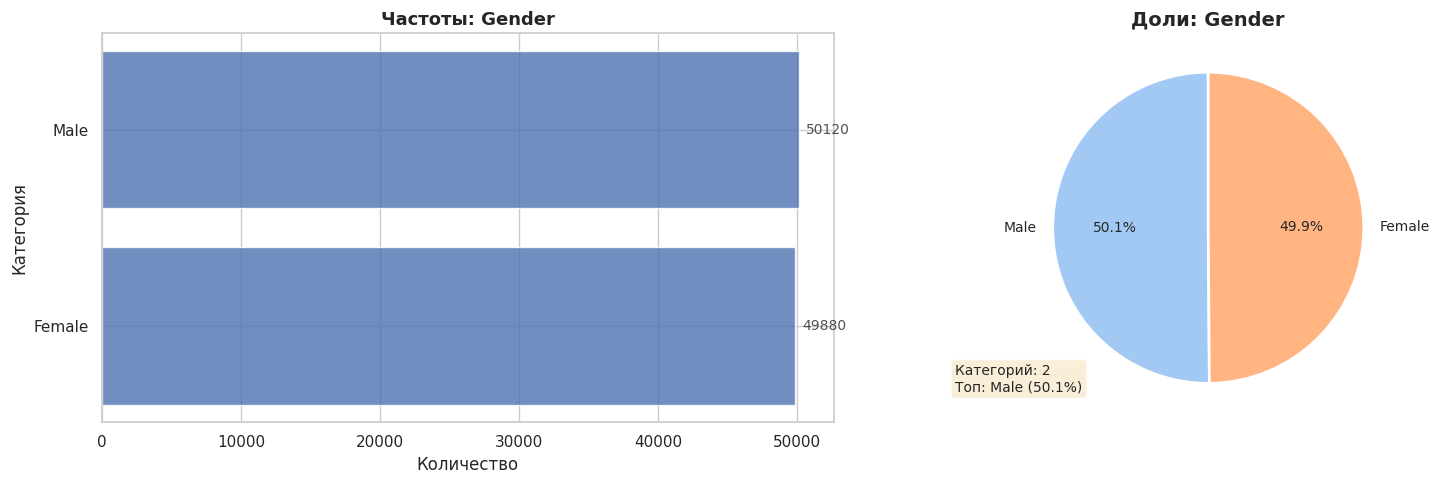

In [172]:
plot_cat_feat(eda_df["Gender"])

Выборка сбалансирована: количество представителей обоих полов практически идентично. Признак является номинальным, поэтому для корректной работы линейных моделей будет применено прямое кодирование `One-Hot Encoding`.

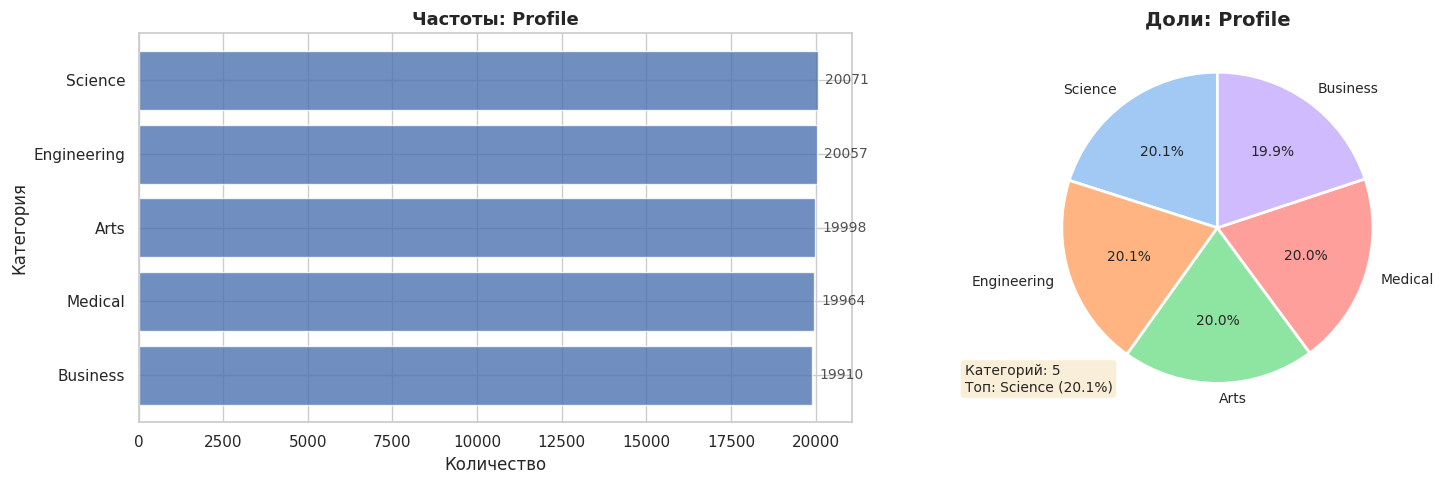

In [173]:
plot_cat_feat(eda_df["Profile"])

В датасете представлены 5 направлений обучения. Наблюдается равномерное распределение: каждая категория занимает ≈20% выборки.

### Поиск связей для регрессии

#### Анализ между числовыми признаками и целевой переменной

Проверим, как по отдельности влияют числовые признаки `Study`, `Sleep`, `Media`, `Sport`, `Stress` на успеваемость `CGPA`.

In [174]:
def plot_num_feat_vs_target(df, feat_col: str, target_col: str):
    plt.figure(figsize=(10, 4))

    sns.regplot(
        data=df,
        x=feat_col,
        y=target_col,
        scatter_kws={"alpha": 0.07, "s": 10},
        line_kws={"color": "red", "lw": 3},
    )
    plt.title(f"Влияние {feat_col} на {target_col}")

    plt.tight_layout()
    plt.show()

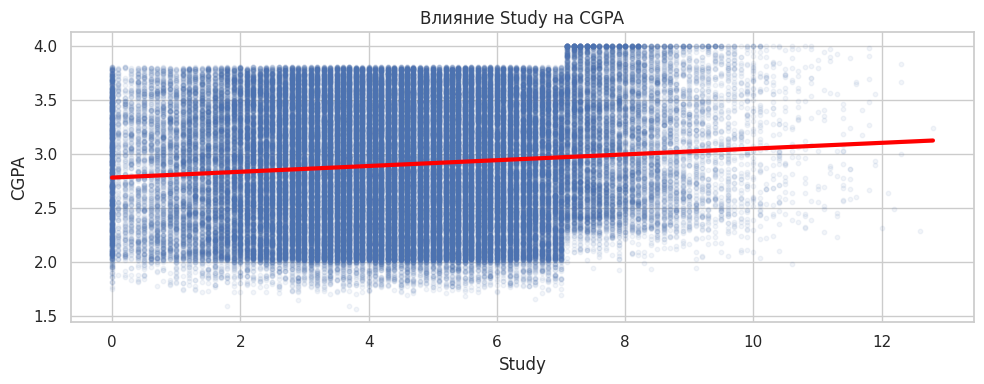

In [175]:
plot_num_feat_vs_target(eda_df, "Study", "CGPA")

Наблюдается отчетивая положительная зависимость. Линия тренда идёт вверх. Увеличение времени на обучение способствует росту академической успеваемости.

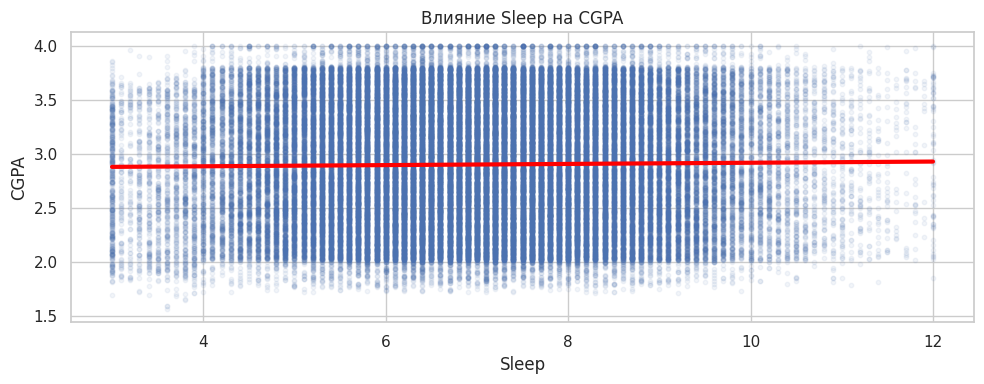

In [176]:
plot_num_feat_vs_target(eda_df, "Sleep", "CGPA")

Линия регрессии практически горизонтальна. Это указывает на крайне слабую линейную зависимость.

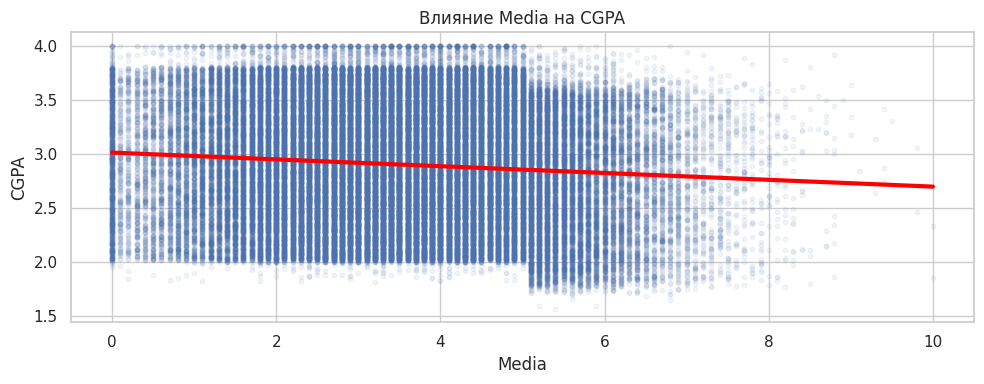

In [177]:
plot_num_feat_vs_target(eda_df, "Media", "CGPA")

Наблюдается отчетливая отрицательная зависимость. С увеличением времени, проводимого в социальных сетях, линия тренда идет вниз. Избыточное нахождение в соц-сетях негативно сказывается академической успеваемости.

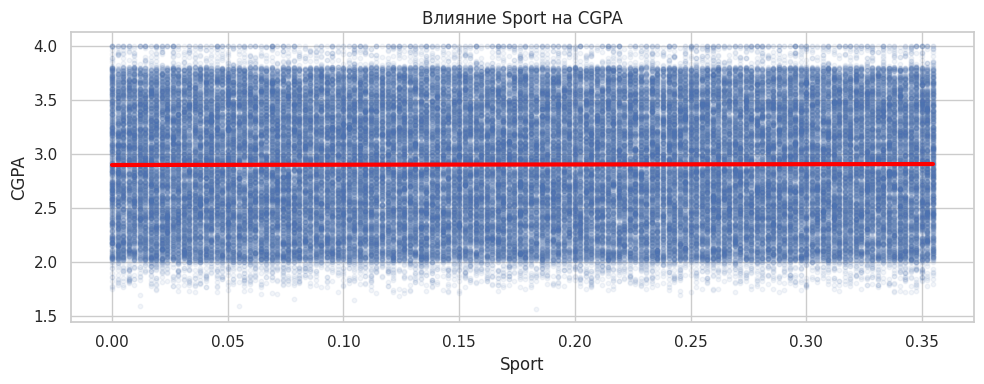

In [178]:
plot_num_feat_vs_target(eda_df, "Sport", "CGPA")

Линия регрессии практически горизонтальна. Это указывает на крайне слабую линейную зависимость.

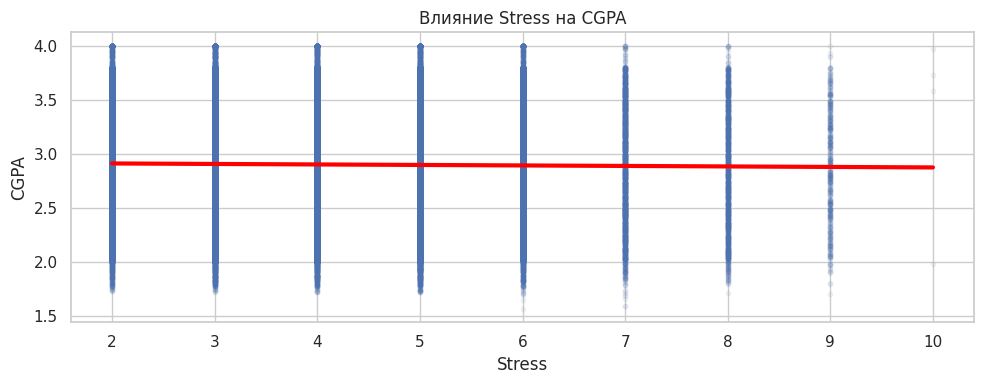

In [179]:
plot_num_feat_vs_target(eda_df, "Stress", "CGPA")

Наблюдается слабая отрицательная зависимость.

#### Выводы на основе визуального анализа
Наблюдаются положительная связь у учебы и успеваемости и отрицательная у соцсетей и успеваемости. Однако во всех случаях наблюдается высокая дисперсия - сильный разброс точек вокруг линии тренда.

#### Анализ между категориальными признаками и целевой переменной

In [180]:
def plot_cat_feat_vs_target(df: pd.DataFrame, feat_col: str, target_col: str):
    plt.figure(figsize=(10, 4))

    order = df.groupby(feat_col)[target_col].median().sort_values(ascending=False).index

    sns.boxplot(
        data=df, x=feat_col, y=target_col, order=order, hue=feat_col, palette="viridis"
    )

    plt.title(
        f"Распределение {target_col} по категориям {feat_col}",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

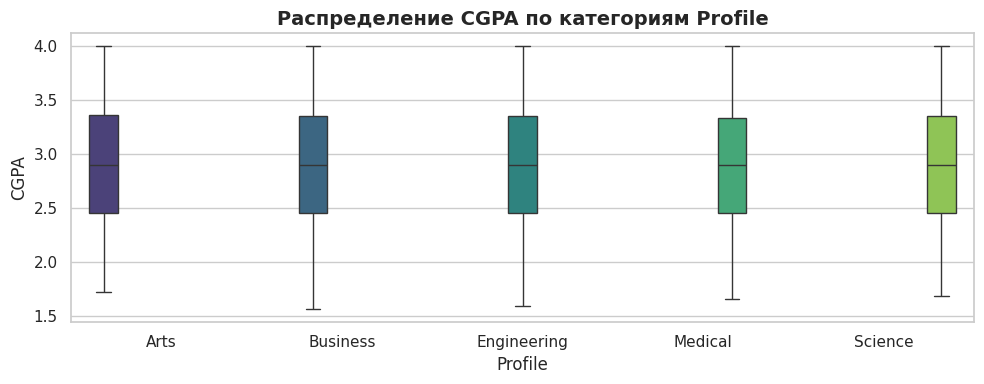

In [181]:
plot_cat_feat_vs_target(eda_df, "Profile", "CGPA")

Медианные значения и межквартильный размах успеваемости совпадает по всем направлениям обучения. Выбор специальности не оказывает сильного влияния на академическую успеваемость.

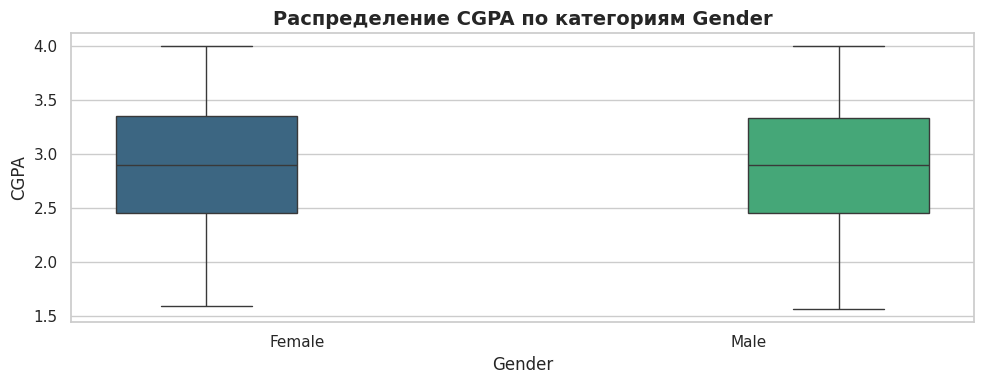

In [182]:
plot_cat_feat_vs_target(eda_df, "Gender", "CGPA")

Медианные значения и межквартильный размах успеваемости совпадает при разделении по полу. Пол не оказывает сильного влияния на академическую успеваемость.

### Поиск связей для классификации

#### Анализ распределения числовых признаков в зависимости от депрессии

In [183]:
def plot_num_feat_vs_cat(df: pd.DataFrame, feat_col: str, target_col: str):
    plt.figure(figsize=(8, 5))

    sns.boxplot(data=df, x=target_col, y=feat_col, hue=target_col, palette="viridis")
    plt.title(
        f"Распределение {feat_col} по категории {target_col}",
        fontsize=14,
        fontweight="bold",
    )

    plt.tight_layout()
    plt.show()

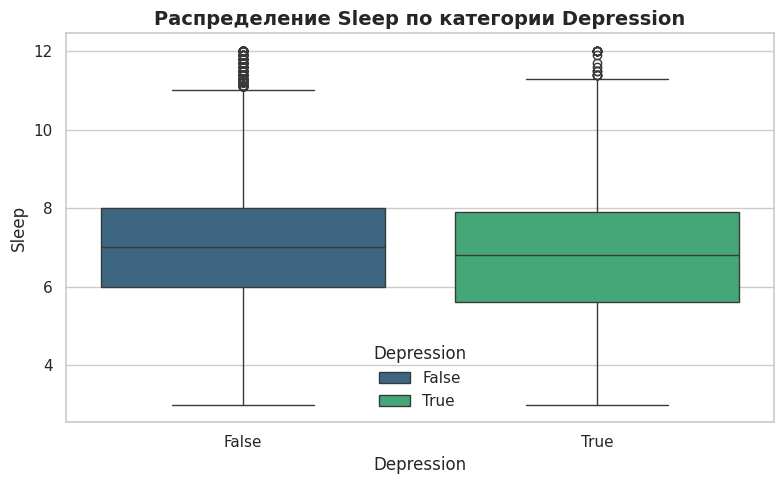

In [184]:
plot_num_feat_vs_cat(eda_df, "Sleep", "Depression")

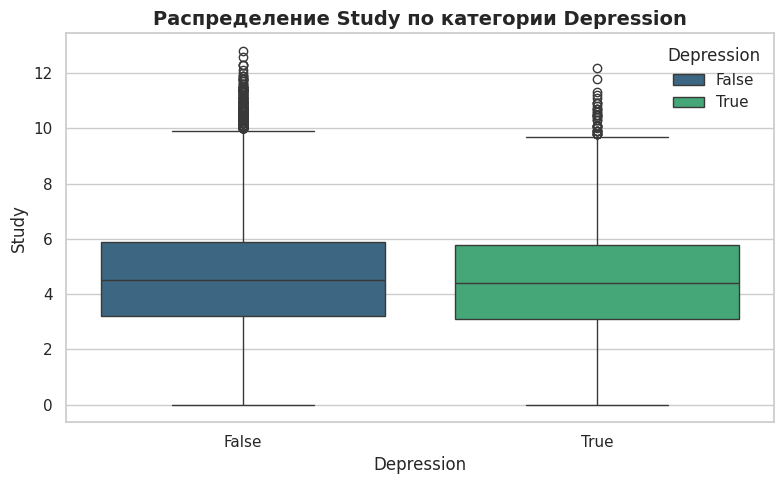

In [185]:
plot_num_feat_vs_cat(eda_df, "Study", "Depression")

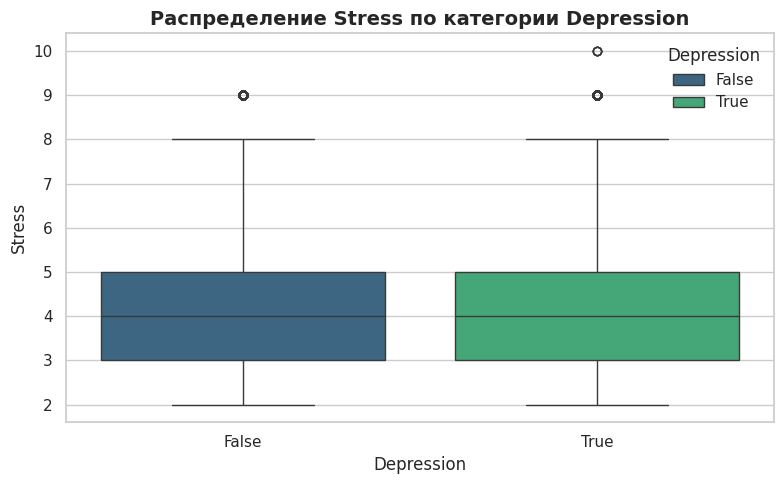

In [186]:
plot_num_feat_vs_cat(eda_df, "Stress", "Depression")

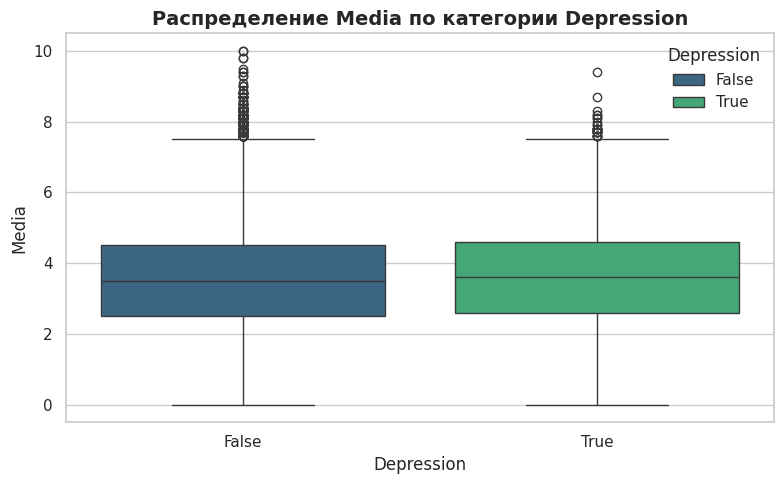

In [187]:
plot_num_feat_vs_cat(eda_df, "Media", "Depression")

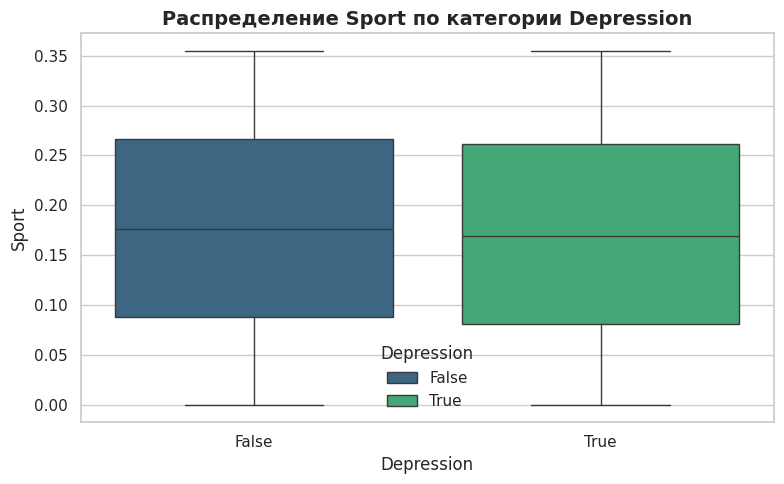

In [188]:
plot_num_feat_vs_cat(eda_df, "Sport", "Depression")

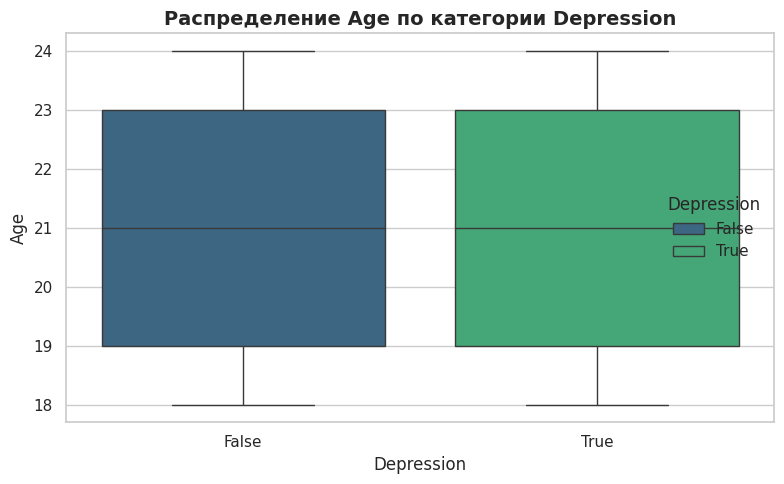

In [189]:
plot_num_feat_vs_cat(eda_df, "Age", "Depression")

#### Выводы на основе визуального анализа
Наблюдения для признаков Sleep, Study, Stress, Media и Sport показал отсутствие выраженных различий в распределениях между группами студентов с депрессией (True) и без неё (False).

#### Анализ распределения категориальных признаков в зависимости от депрессии

In [190]:
def plot_cat_feat_vs_cat(df: pd.DataFrame, feat_col: str, target_col: str):
    plt.figure(figsize=(10, 5))

    sns.countplot(data=df, x=target_col, hue=feat_col)
    plt.title(
        f"Распределение {target_col} внутри категории {feat_col}",
        fontsize=14,
        fontweight="bold",
    )
    plt.ylabel("Количество")

    plt.tight_layout()
    plt.show()

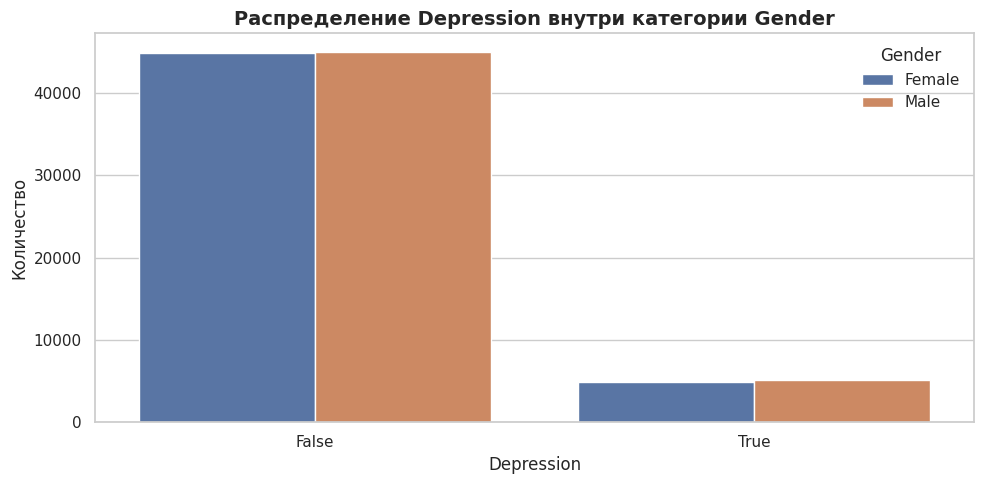

In [191]:
plot_cat_feat_vs_cat(eda_df, "Gender", "Depression")

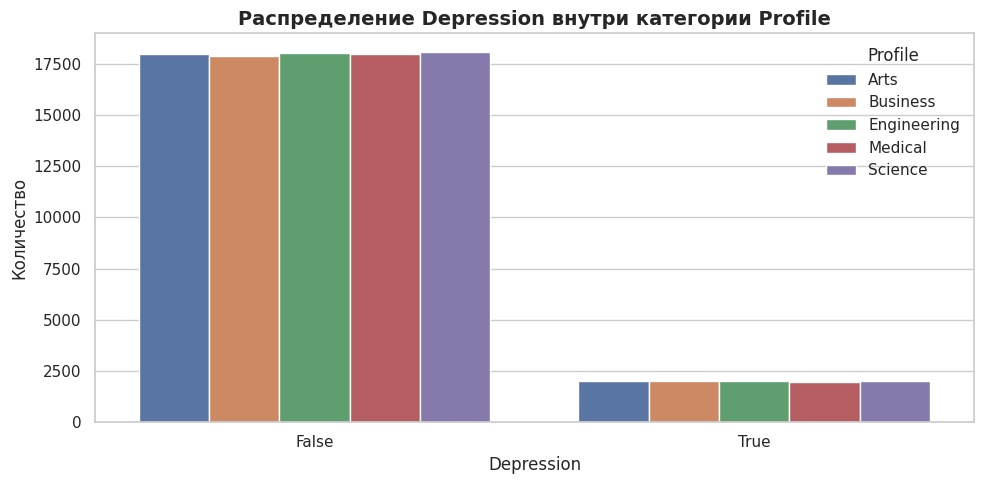

In [192]:
plot_cat_feat_vs_cat(eda_df, "Profile", "Depression")

#### Выводы на основе визуального анализа
Графики подтверждают отсутствие прямой зависимости между категориальными признаками `Gender`, `Profile` и целевой переменной Depression.

### Анализ связи между целевыми переемнными

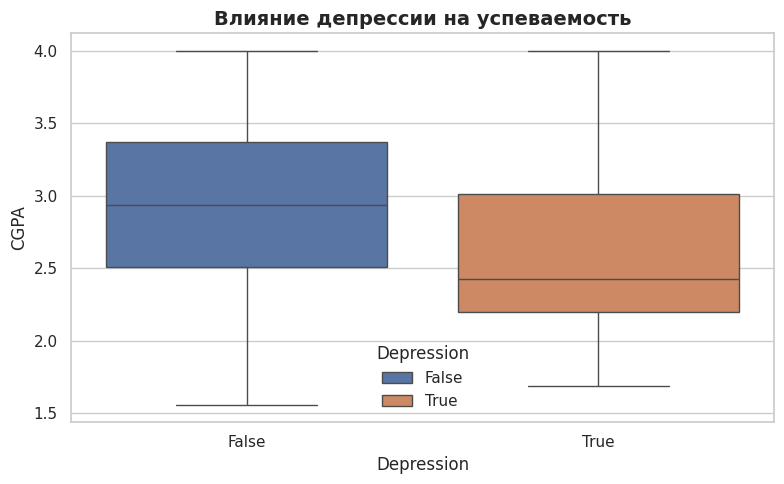

Depression
False    2.94
True     2.43
Name: CGPA, dtype: float64


In [193]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=eda_df, x="Depression", y="CGPA", hue="Depression")
plt.title("Влияние депрессии на успеваемость", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

print(eda_df.groupby("Depression")["CGPA"].median())

#### Выводы на основе визуального анализа
По графику видно, что наблюдается сильная отрицательная связь таргетов `Depression` и `CGPA`. Медиана успеваемости людей с депрессией (≈2.4) значительно ниже чем у здоровых (≈2.9). При этом границы ящиков (межквартильные размахи) пересекаются, но медиана группы с депрессией ниже нижней границы (Q1) здоровых людей. Это будет важным признаком для модели.

### Анализ корреляций между признаками

In [194]:
corr_df = eda_df.select_dtypes(include=["number", "bool"]).copy()
corr_df["Depression"] = corr_df["Depression"].astype(int)

In [195]:
from typing import Literal


def plot_correlation_heatmaps(
    df: pd.DataFrame, method: Literal["pearson", "spearman"], size: float = 7
):
    plt.figure(figsize=(size, size))

    titles = {
        "pearson": "Корреляция Пирсона (Линейная)",
        "spearman": "Корреляция Спирмена (Монотонная)",
    }

    numeric = df.select_dtypes(include=[np.number])
    corr = numeric.corr(method=method)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    sns.heatmap(
        data=corr,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",
        center=0,
        mask=mask,
        linewidths=0.5,
        cbar_kws={"shrink": 0.75},
        square=True,
    )
    plt.title(titles[method], fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

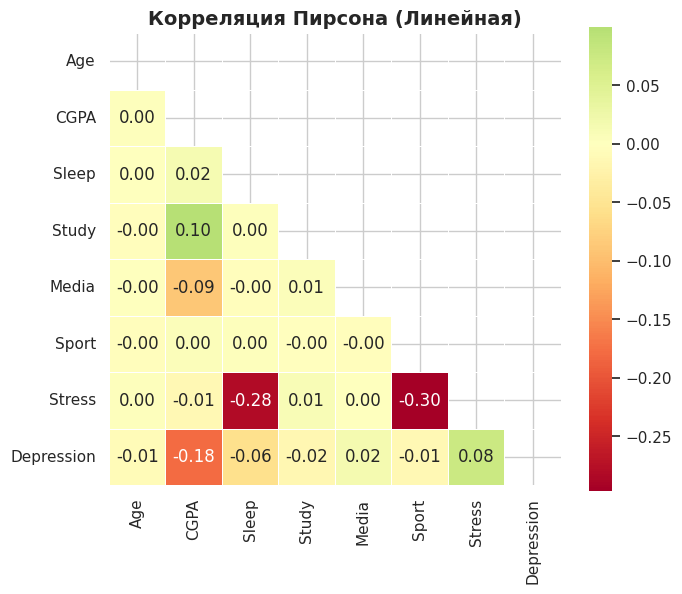

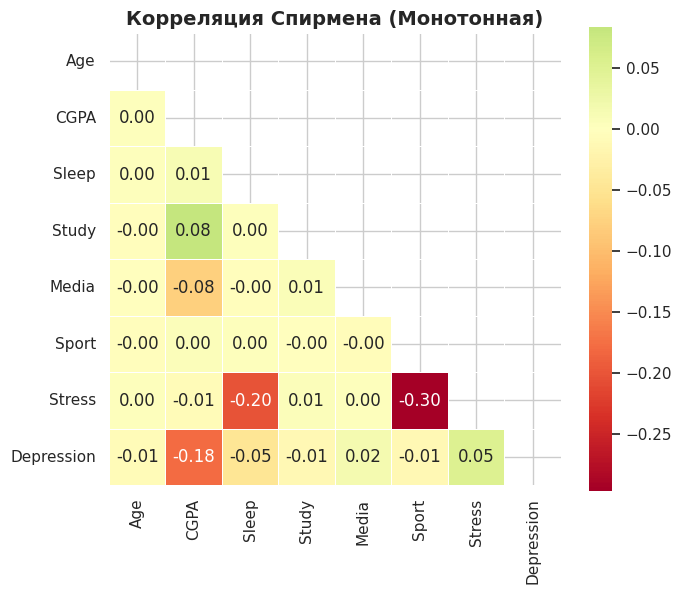

In [196]:
plot_correlation_heatmaps(corr_df, "pearson")
plot_correlation_heatmaps(corr_df, "spearman")

#### Выводы по корреляции
Наиболее значимый фактор для `CGPA` - наличие депрессии (-0.18). Часы учебы `Study` имеют слабую положительную связь (0.10). Выявлены отрицательные связи: спорт (-0.30) и сон (-0.28) способствуют снижению стресса. Коэффициенты Пирсона и Спирмена практически идентичны. Отсутствие высокой корреляции между признаками гарантирует отсутствие мультиколлинеарности.

## Feature Engineering


In [197]:
final_df = df.copy()

# Приводим тип
final_df["Depression"] = final_df["Depression"].astype(int)

# Произведение времени учебы на медиа
final_df["study_x_media"] = final_df["Study"] * final_df["Media"]

# Произвдеение стрессса на учёбу
final_df["study_x_stress"] = final_df["Study"] * final_df["Stress"]

# Бинарный признак недосыпа
final_df["sleep_deprived"] = (final_df["Sleep"] < 5).astype(int)

# Бинарный признак много учёбы
final_df["study_lot"] = (final_df["Study"] > 6).astype(int)


In [198]:
# Коэффицент отношения сна к стрессу
# final_df["recovery_ratio"] = final_df["Sleep"] / (final_df["Stress"] + 1)

# Отношение учебы к времени за медиа и спортом
# final_df["study_/_media_sport"] = final_df["Study"] / (final_df["Media"] + final_df["Sport"])

# Отношение учебы к времени за медиа, сном и спортом
# final_df["study_/_media_sport_sleep"] = final_df["Study"] / (final_df["Media"] + final_df["Sport"] + final_df["Sleep"])

# Квадрат учёбы
# final_df["study_sq"] = final_df["Study"] ** 2

# Квадрат соцсетей
# final_df["media_sq"] = final_df["Media"] ** 2

# Квадрат спорта
# final_df["sport_sq"] = final_df["Sport"] ** 2

# Квадрат сна
# final_df["sleep_sq"] = final_df["Sleep"] ** 2

# Квадрат стресса
# final_df["stress_sq"] = final_df["Stress"] ** 2

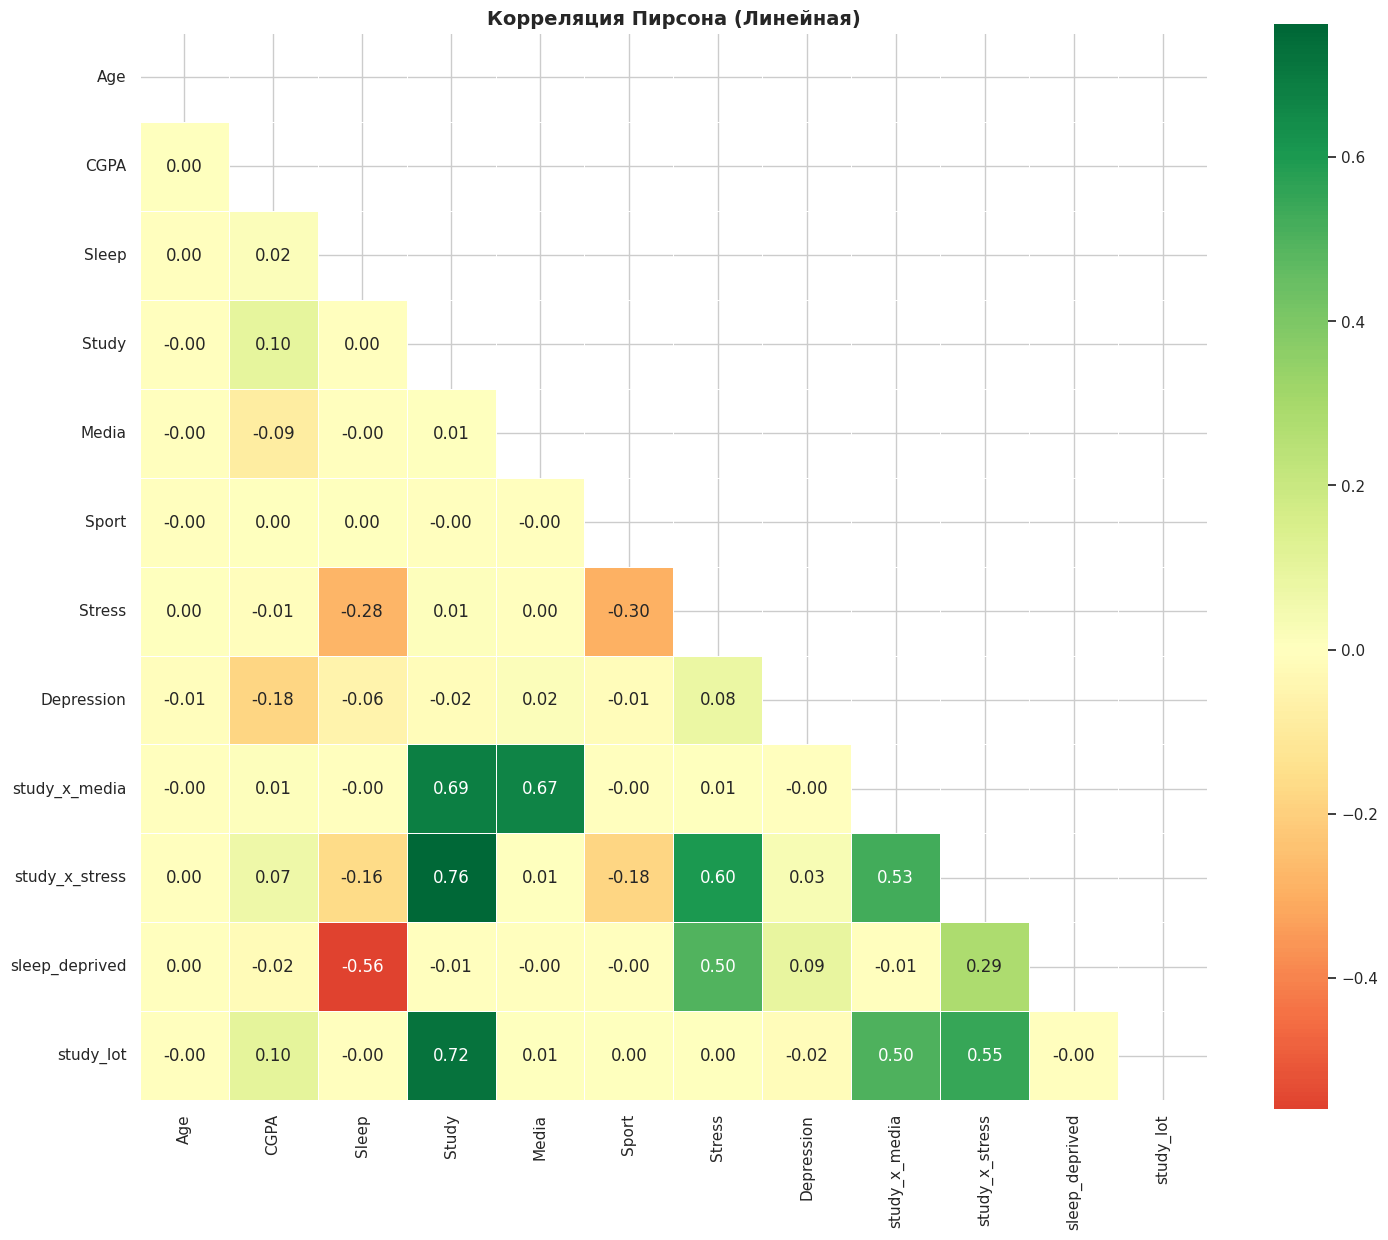

In [199]:
plot_correlation_heatmaps(final_df, "pearson", 15)

### Выводы по инженерии признаков
Был првоерен ряд признаков:
1. Полиномиальные признаки (квадраты) показали высокую коллинеарность (> 0.94) с исходными. Для предотвращения нестабильности весов линейной регрессии и переобучения было решено исключить данные признаки;
2. Коэффицент отношения сна к стрессу показал высокую коллинеарность со стрессом (-0.83), при этом не улучшив связи с признаками. Признак удален как избыточный;
3. Признак `study_x_stress` и флаг `study_lot` показали корреляцию с успеваемостью и позволяют модели учитывать нелинейный вклад учебных часов;
4. Флаг `sleep_deprived` также имеет корреляцию с целевой переменной `Depression`.
Проверенные неудачные признаки закоментированы.

## Разделение на выборки без утечки

In [200]:
from sklearn.model_selection import train_test_split

train_full_df, test_df = train_test_split(
    final_df, test_size=0.2, random_state=42, shuffle=True
)
train_df, val_df = train_test_split(
    train_full_df, test_size=0.25, random_state=42, shuffle=True
)

print(f"Обучение: {train_df.shape}, Валидация: {val_df.shape}, Тест: {test_df.shape}")

Обучение: (60000, 14), Валидация: (20000, 14), Тест: (20000, 14)


## Предобработка

Применяем обработку выбросов (винзонирование) - выбросы заменяеются на выбранные значения ближайших границ.

In [201]:
# Определяем колонки с выбросами
def get_outliers_count(df: pd.DataFrame, col_name: str):
    col = df[col_name]

    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    upper_outliers = (col > upper_bound).sum()
    lower_outliers = (col < lower_bound).sum()

    return upper_outliers, lower_outliers


numeric_feat = train_df.select_dtypes(include=["number"]).columns.to_list()
# Убираем таргеты и бинарные признаки
for target in ["Depression", "CGPA"]:
    if target in numeric_feat:
        numeric_feat.remove(target)

cols_to_winsorize = []
for col in numeric_feat:
    if train_df[col].nunique() <= 2:  # Пропускаем бинарные признаки
        continue

    up, low = get_outliers_count(train_df, col)
    if up > 0 or low > 0:
        print(f"В колонке {col:15} обнаружены выбросы: сверху {up}, снизу {low}")
        cols_to_winsorize.append(col)

В колонке Sleep           обнаружены выбросы: сверху 201, снизу 0
В колонке Study           обнаружены выбросы: сверху 252, снизу 0
В колонке Media           обнаружены выбросы: сверху 194, снизу 0
В колонке Stress          обнаружены выбросы: сверху 284, снизу 0
В колонке study_x_media   обнаружены выбросы: сверху 1056, снизу 0
В колонке study_x_stress  обнаружены выбросы: сверху 1134, снизу 0


In [202]:
from feature_engine.outliers import Winsorizer

# Винзоризатор
winsorizer = Winsorizer(
    capping_method="iqr", fold=1.5, tail="right", variables=cols_to_winsorize
)

# Обучаем на train
winsorizer.fit(train_df)

# Применяем ко всему
train_df = winsorizer.transform(train_df)
val_df = winsorizer.transform(val_df)
test_df = winsorizer.transform(test_df)

Применим кодирвоание категориальных признаков One-Hot Encoging.

In [203]:
from feature_engine.encoding import OneHotEncoder

cat_features = ["Gender", "Profile"]

# One-Hot Encoging
ohe = OneHotEncoder(variables=cat_features, drop_last=True)
# drop_last позволяет избежать мультиколлинеарности

# Обучаем на train
ohe.fit(train_df)

# Применяем ко всему
train_df = ohe.transform(train_df)
val_df = ohe.transform(val_df)
test_df = ohe.transform(test_df)

Подготовим данные для регрессии.

In [204]:
X_reg_train = train_df.drop(columns=["CGPA"])
y_reg_train = train_df["CGPA"]

X_reg_val = val_df.drop(columns=["CGPA"])
y_reg_val = val_df["CGPA"]

X_reg_test = test_df.drop(columns=["CGPA"])
y_reg_test = test_df["CGPA"]

Подготовим данные для классификации.

In [205]:
X_clf_train = train_df.drop(columns=["Depression"])
y_clf_train = train_df["Depression"]

X_clf_val = val_df.drop(columns=["Depression"])
y_clf_val = val_df["Depression"]

X_clf_test = test_df.drop(columns=["Depression"])
y_clf_test = test_df["Depression"]

Теперь применим масштабирвование для регрессии.

In [206]:
from sklearn.preprocessing import StandardScaler

# StandardScaler
scaler_reg = StandardScaler()

# Обучаем на train
scaler_reg.fit(X_reg_train)

# Применяем ко всему (результат преобразуем к data-frame)
# Таргет не масштабируем для интерпретируемости
X_reg_train = pd.DataFrame(
    scaler_reg.transform(X_reg_train),
    columns=X_reg_train.columns,
    index=X_reg_train.index,
)
X_reg_val = pd.DataFrame(
    scaler_reg.transform(X_reg_val), columns=X_reg_val.columns, index=X_reg_val.index
)
X_reg_test = pd.DataFrame(
    scaler_reg.transform(X_reg_test), columns=X_reg_test.columns, index=X_reg_test.index
)

Теперь применим масштабирвование для классификации.

In [207]:
from sklearn.preprocessing import StandardScaler

# StandardScaler
scaler_clf = StandardScaler()

# Обучаем на train
scaler_clf.fit(X_clf_train)

# Применяем ко всему (результат преобразуем к data-frame)
# Таргет не масштабируем для интерпретируемости
X_clf_train = pd.DataFrame(
    scaler_clf.transform(X_clf_train),
    columns=X_clf_train.columns,
    index=X_clf_train.index,
)
X_clf_val = pd.DataFrame(
    scaler_clf.transform(X_clf_val), columns=X_clf_val.columns, index=X_clf_val.index
)
X_clf_test = pd.DataFrame(
    scaler_clf.transform(X_clf_test), columns=X_clf_test.columns, index=X_clf_test.index
)

## Обучение линейной регрессии

In [208]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)

model_reg = LinearRegression()
model_reg.fit(X_reg_train, y_reg_train)

y_reg_train_pred = model_reg.predict(X_reg_train)
y_reg_val_pred = model_reg.predict(X_reg_val)


def evaluate_model(y_true, y_pred, name):
    """Расчет и вывод метрик качества"""
    mae = mean_absolute_error(y_true, y_pred)  # Средняя абсолютная ошибка
    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )  # Корень из среднеквадратичной ошибки
    mape = (
        mean_absolute_percentage_error(y_true, y_pred) * 100
    )  # Средняя абсолютная ошибка в процентах
    r2 = r2_score(y_true, y_pred)  # R^2

    print(f"Метрики для {name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

Метрики для Train:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0533
  MAPE: 16.09%
Метрики для Validation:
  MAE:  0.44
  RMSE: 0.52
  R²:   0.0485
  MAPE: 16.14%


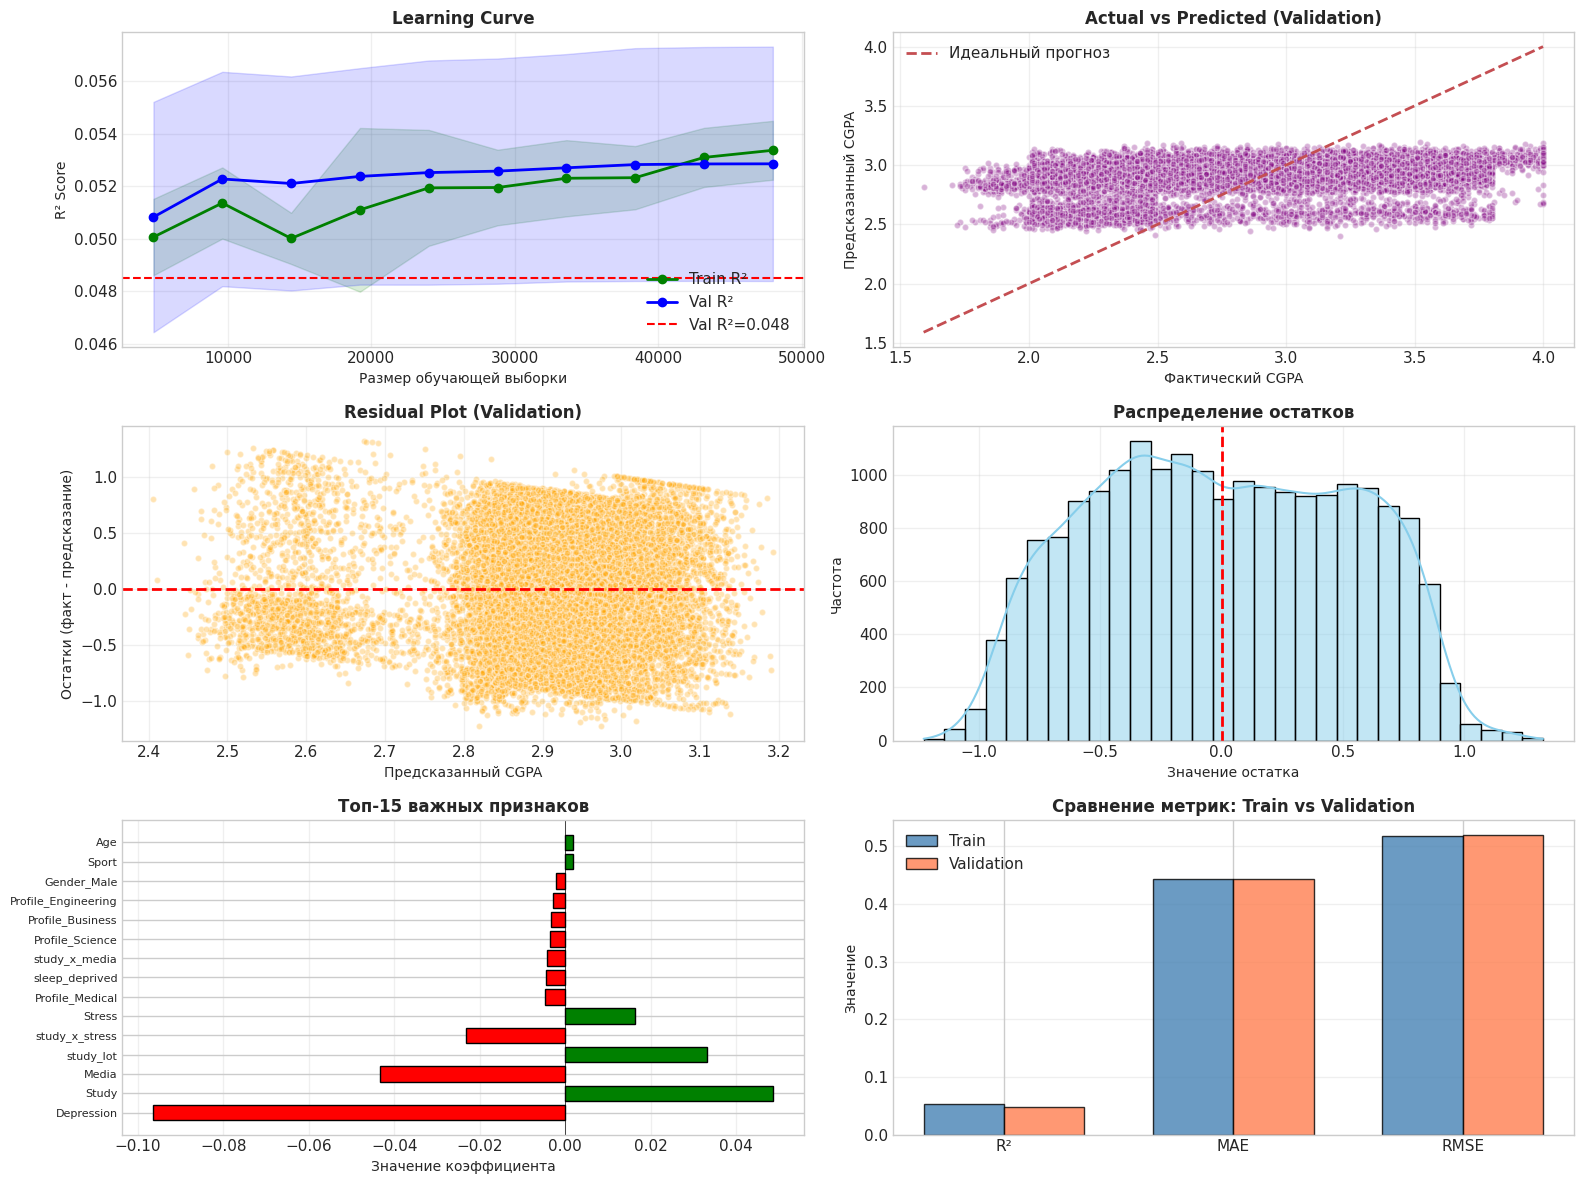

In [209]:
from sklearn.model_selection import learning_curve

plt.style.use("seaborn-v0_8-whitegrid")
fig = plt.figure(figsize=(16, 12))

# Считаем метрики
train_metrics = evaluate_model(y_reg_train, y_reg_train_pred, "Train")
val_metrics = evaluate_model(y_reg_val, y_reg_val_pred, "Validation")

# Кривая обучения
ax1 = plt.subplot(3, 2, 1)

train_sizes, train_scores, val_scores, *_ = learning_curve(
    model_reg,
    X_reg_train,
    y_reg_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="r2",
    n_jobs=-1,
)

train_mean = np.mean(train_scores, axis=1)  # среднее арифметическое
train_std = np.std(train_scores, axis=1)  # среднеквадратичное отклонение
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

ax1.plot(train_sizes, train_mean, "o-", color="green", label="Train R²", linewidth=2)
ax1.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color="green",
)
ax1.plot(train_sizes, val_mean, "o-", color="blue", label="Val R²", linewidth=2)
ax1.fill_between(
    train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="blue"
)
ax1.set_xlabel("Размер обучающей выборки", fontsize=10)
ax1.set_ylabel("R² Score", fontsize=10)
ax1.set_title("Learning Curve", fontsize=12, fontweight="bold")
ax1.grid(True, alpha=0.3)
ax1.axhline(
    y=val_metrics["R2"],
    color="red",
    linestyle="--",
    lw=1.5,
    label=f"Val R²={val_metrics['R2']:.3f}",
)
ax1.legend(loc="lower right")

# Реальность vs Предсказание
ax2 = plt.subplot(3, 2, 2)
ax2.scatter(
    y_reg_val, y_reg_val_pred, alpha=0.3, edgecolors="white", s=20, color="purple"
)
ax2.plot(
    [y_reg_val.min(), y_reg_val.max()],
    [y_reg_val.min(), y_reg_val.max()],
    "r--",
    lw=2,
    label="Идеальный прогноз",
)
ax2.set_xlabel("Фактический CGPA", fontsize=10)
ax2.set_ylabel("Предсказанный CGPA", fontsize=10)
ax2.set_title("Actual vs Predicted (Validation)", fontsize=12, fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Остатки
ax3 = plt.subplot(3, 2, 3)
residuals = y_reg_val - y_reg_val_pred
ax3.scatter(
    y_reg_val_pred, residuals, alpha=0.3, edgecolors="white", s=20, color="orange"
)
ax3.axhline(y=0, color="red", linestyle="--", lw=2)
ax3.set_xlabel("Предсказанный CGPA", fontsize=10)
ax3.set_ylabel("Остатки (факт - предсказание)", fontsize=10)
ax3.set_title("Residual Plot (Validation)", fontsize=12, fontweight="bold")
ax3.grid(True, alpha=0.3)

# Распределение остатков
ax4 = plt.subplot(3, 2, 4)
sns.histplot(residuals, bins=30, kde=True, ax=ax4, color="skyblue", edgecolor="black")
ax4.axvline(x=0, color="red", linestyle="--", lw=2)
ax4.set_xlabel("Значение остатка", fontsize=10)
ax4.set_ylabel("Частота", fontsize=10)
ax4.set_title("Распределение остатков", fontsize=12, fontweight="bold")
ax4.grid(True, alpha=0.3)

# Коэффициенты модели (Топ-15 по модулю)
ax5 = plt.subplot(3, 2, 5)
coefficients = pd.DataFrame({"feature": X_reg_train.columns, "coef": model_reg.coef_})
coefficients = coefficients.sort_values(
    by="coef", key=lambda x: np.abs(x), ascending=False
).head(15)

colors = ["green" if c > 0 else "red" for c in coefficients["coef"]]
bars = ax5.barh(
    coefficients["feature"], coefficients["coef"], color=colors, edgecolor="black"
)
ax5.set_xlabel("Значение коэффициента", fontsize=10)
ax5.set_title("Топ-15 важных признаков", fontsize=12, fontweight="bold")
ax5.grid(True, alpha=0.3, axis="x")
ax5.axvline(x=0, color="black", lw=0.5)
plt.setp(ax5.get_yticklabels(), fontsize=8)

# Сравнение метрик Train/Validation
ax6 = plt.subplot(3, 2, 6)
metrics_names = ["R²", "MAE", "RMSE"]
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics["R2"], train_metrics["MAE"], train_metrics["RMSE"]]
val_vals = [val_metrics["R2"], val_metrics["MAE"], val_metrics["RMSE"]]

ax6.bar(
    x_pos - width / 2,
    train_vals,
    width,
    label="Train",
    alpha=0.8,
    edgecolor="black",
    color="steelblue",
)
ax6.bar(
    x_pos + width / 2,
    val_vals,
    width,
    label="Validation",
    alpha=0.8,
    edgecolor="black",
    color="coral",
)
ax6.set_xticks(x_pos)
ax6.set_xticklabels(metrics_names)
ax6.set_ylabel("Значение", fontsize=10)
ax6.set_title("Сравнение метрик: Train vs Validation", fontsize=12, fontweight="bold")
ax6.legend()
ax6.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

#### Анализ качества модели линейной регрессии
1. Метрики на обучающей и валидационной выборках практически идентичны. Это показывает отсутствие переобучения;
2.  $R^2$ составляет около 5%. Это означает, что линейной модели не хватает чтобы описать зависимости в этом датасете, либо таргет определяется признаками, не представленными в этом датасете;
3. Средняя абсолютная ошибка (MAE) составляет 0.44 балла. В контексте шкалы от 0.0 до 4.0 это означает погрешность в 16% т.е. точность прогноза 84%;
4. На графике `Actual vs Predicted` видно горизонтальное облако точек, это означает, что модель стремится выдавать значения, близкие к среднему;
5. График остатков практически симметричен относительно нуля, однако разброс ошибок значительный на всем диапазоне предсказаний;
5.  Самым важным признаком оказался `Depression` (отрицательное влияние) и `Study` (положительное влияние). Новые признаки, такие как `study_lot` и `study_x_stress`, вошли в топ-5 по важности.

## Обучение логистической регрессии

In [210]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    log_loss,
)
from sklearn.utils.class_weight import compute_class_weight

# Поскольку есть дисбаланс классов (10% больных, 90% здоровых)
# То можно использовтаь взвешивание классов
# За ошибку на редком классе будет больший штраф
classes = np.unique(y_clf_train)

weights = compute_class_weight(
    class_weight='balanced', 
    classes=classes, 
    y=y_clf_train
)
class_weights_dict = {classes[0]: weights[0], classes[1]: weights[1]}

# Параметры, для того чтобы можно было легко пробовать новые комбинации натсроек
lr = 0.001  # Шаг обучения (learning rate)
epochs = 100  # Количество эпох
alpha = 0.0001  # Коэффицент регуляризации (не позволяет весам быть слишком большими)

# Стохастический градиентный спуск
model_clf = SGDClassifier(
    loss="log_loss",  # Логистическая регрессия
    learning_rate="constant",
    eta0=lr,
    alpha=alpha,
    class_weight=class_weights_dict,
    random_state=42,
)

# Для того, чтобы построить график потерь (Loss) нужно будет обучать по одной эпохе вручную,
# и сохранять ошибку
loss_history = []

print("Начинаем обучение")
print(
    f"Параметры: шаг обучения {lr=}, эпох {epochs=}, коэффицент регуляризации {alpha=}"
)

predict_classes = np.unique(y_clf_train)  # [0 1] в отсортированном порядке
for epoch in range(epochs):
    # Обучение одной эпохи
    model_clf.partial_fit(X_clf_train, y_clf_train, classes=predict_classes)

    # Запускаем модель для предсказания вероятностей
    y_proba = model_clf.predict_proba(X_clf_train)

    # Стичаем LogLoss для этой эпохи
    loss_history.append(log_loss(y_clf_train, y_proba))

# запускаем прогнозы
y_clf_train_pred = model_clf.predict(X_clf_train)
y_clf_val_pred = model_clf.predict(X_clf_val)

# Берем предсказанные вероятности депрессии
y_clf_train_proba = model_clf.predict_proba(X_clf_train)[:, 1]
y_clf_val_proba = model_clf.predict_proba(X_clf_val)[:, 1]

print("Готов")

Начинаем обучение
Параметры: шаг обучения lr=0.001, эпох epochs=100, коэффицент регуляризации alpha=0.0001
Готов


In [211]:
def evaluate_classification(y_true, y_pred, y_proba=None, name: str = ""):
    """Расчет и вывод метрик классификации"""
    acc = accuracy_score(y_true, y_pred)  # Доля правильных ответов (TN + TP / All)
    pre = precision_score(y_true, y_pred, zero_division=0)  # Точность (TP / TP + FP)
    rec = recall_score(y_true, y_pred, zero_division=0)  # Полнота (TP / TP + FN)
    f1 = f1_score(
        y_true, y_pred, zero_division=0
    )  # Оценивает баланс между Precision и Recall
    auc = (
        roc_auc_score(y_true, y_proba) if y_proba is not None else 0
    )  # Оценивает ранжирующую способность модели

    print(f"\nМетрики для {name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {pre:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  AUC-ROC:   {auc:.4f}")

    return {"Accuracy": acc, "Precision": pre, "Recall": rec, "F1": f1, "AUC-ROC": auc}


Метрики для Train:
  Accuracy:  0.6226
  Precision: 0.1704
  Recall:    0.7003
  F1-Score:  0.2741
  AUC-ROC:   0.6903

Метрики для Validation:
  Accuracy:  0.6221
  Precision: 0.1654
  Recall:    0.7088
  F1-Score:  0.2682
  AUC-ROC:   0.6837


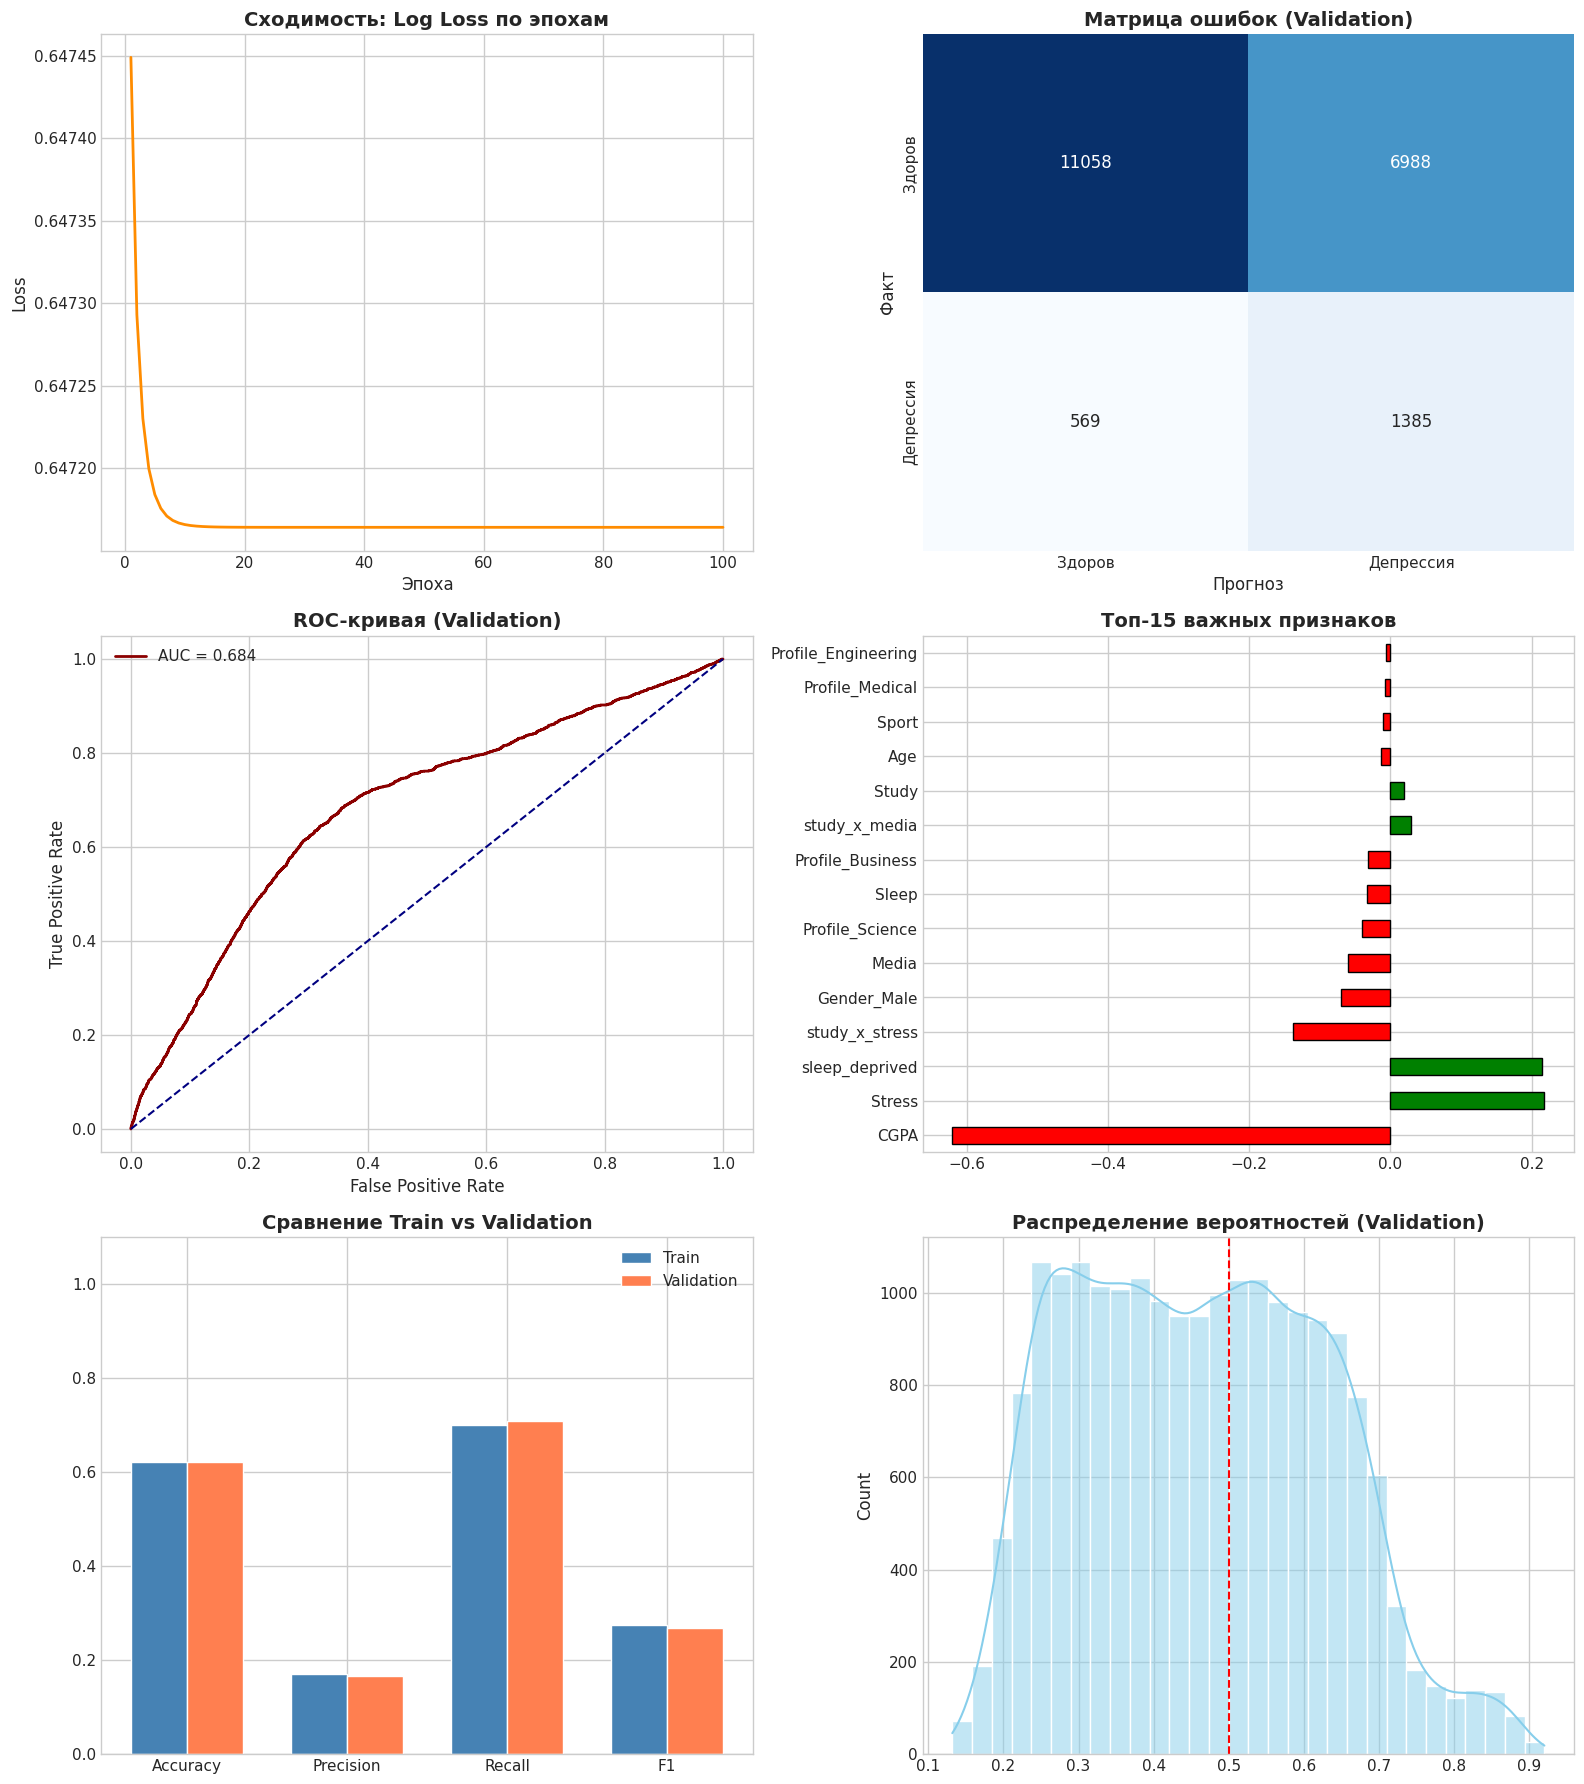

In [212]:
# Оцениваем метрики
train_metrics_clf = evaluate_classification(
    y_clf_train, y_clf_train_pred, y_clf_train_proba, name="Train"
)
val_metrics_clf = evaluate_classification(
    y_clf_val, y_clf_val_pred, y_clf_val_proba, name="Validation"
)

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

# Loss History (Log Loss по эпохам)
axes[0].plot(range(1, epochs + 1), loss_history, color="darkorange", lw=2)
axes[0].set_title("Сходимость: Log Loss по эпохам", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")

# Матрица ошибок Validation (Confusion Matrix)
cm = confusion_matrix(y_clf_val, y_clf_val_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar=False)
axes[1].set_title("Матрица ошибок (Validation)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Факт")
axes[1].set_xticklabels(["Здоров", "Депрессия"])
axes[1].set_yticklabels(["Здоров", "Депрессия"])

# Ранжирующую способность модели (ROC Curve)
fpr, tpr, _ = roc_curve(y_clf_val, y_clf_val_proba)
axes[2].plot(
    fpr, tpr, color="darkred", lw=2, label=f"AUC = {val_metrics_clf['AUC-ROC']:.3f}"
)
axes[2].plot([0, 1], [0, 1], color="navy", linestyle="--")
axes[2].set_title("ROC-кривая (Validation)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].legend()

# Веса признаков
weights = (
    pd.Series(model_clf.coef_[0], index=X_clf_train.columns)
    .sort_values(key=abs, ascending=False)
    .head(15)
)
colors = ["green" if w > 0 else "red" for w in weights]
weights.plot(kind="barh", ax=axes[3], color=colors, edgecolor="black")
axes[3].set_title("Топ-15 важных признаков", fontsize=14, fontweight="bold")

# Сравнение метрик
m_names = ["Accuracy", "Precision", "Recall", "F1"]
train_v = [train_metrics_clf[k] for k in m_names]
val_v = [val_metrics_clf[k] for k in m_names]

x = np.arange(len(m_names))
width = 0.35
axes[4].bar(x - width / 2, train_v, width, label="Train", color="steelblue")
axes[4].bar(x + width / 2, val_v, width, label="Validation", color="coral")
axes[4].set_xticks(x)
axes[4].set_xticklabels(m_names)
axes[4].set_title("Сравнение Train vs Validation", fontsize=14, fontweight="bold")
axes[4].set_ylim(0, 1.1)
axes[4].legend()

# Распределение вероятностей
sns.histplot(y_clf_val_proba, bins=30, kde=True, ax=axes[5], color="skyblue")
axes[5].axvline(0.5, color="red", linestyle="--")
axes[5].set_title(
    "Распределение вероятностей (Validation)", fontsize=14, fontweight="bold"
)

plt.tight_layout()
plt.show()

In [213]:
print("Анализ порогов для оптимизации F1-Score:")

thresholds = np.arange(0.2, 0.8, 0.05).tolist()
for t in thresholds:
    y_pred_t = (y_clf_val_proba >= t).astype(int)
    f1 = f1_score(y_clf_val, y_pred_t, zero_division=0)
    acc = accuracy_score(y_clf_val, y_pred_t)
    rec = recall_score(y_clf_val, y_pred_t, zero_division=0)
    
    print(f"  Порог {t:.2f}: F1={f1:.4f}, Recall={rec:.4f}, Accuracy={acc:.4f}")

Анализ порогов для оптимизации F1-Score:
  Порог 0.20: F1=0.1795, Recall=0.9857, Accuracy=0.1197
  Порог 0.25: F1=0.1853, Recall=0.9452, Accuracy=0.1880
  Порог 0.30: F1=0.1968, Recall=0.9002, Accuracy=0.2819
  Порог 0.35: F1=0.2065, Recall=0.8429, Accuracy=0.3673
  Порог 0.40: F1=0.2215, Recall=0.7938, Accuracy=0.4548
  Порог 0.45: F1=0.2429, Recall=0.7574, Accuracy=0.5387
  Порог 0.50: F1=0.2682, Recall=0.7088, Accuracy=0.6221
  Порог 0.55: F1=0.2850, Recall=0.6105, Accuracy=0.7006
  Порог 0.60: F1=0.2802, Recall=0.4678, Accuracy=0.7652
  Порог 0.65: F1=0.2412, Recall=0.2922, Accuracy=0.8204
  Порог 0.70: F1=0.1825, Recall=0.1546, Accuracy=0.8647
  Порог 0.75: F1=0.1458, Recall=0.1003, Accuracy=0.8851
  Порог 0.80: F1=0.1146, Recall=0.0706, Accuracy=0.8933


### Анализ модели логистической регрессии
1. Исходное распределение целевой переменной крайне неравномерно: 90% без депрессии, 10% с депрессией.
Был использован метод взвешивания классов: веса рассчитывались автоматически на основе обучающей выборки: класс `депрессия` получил вес примерно 9 раз больше, чем класс `здоров`. Это позволилдо сильно воднять полноту, без этого полнота была близка к 0, тепепрь полнота около 70%;
2. Метрики для тестовой и валидационной выборки практически однаковы, ото показывает отсутсвие переобучения. Для медицинских задач наблюдается компромис между метрикой точностью и полнотой. Для того чтобы обеспечить высокую метрику полноы `Recall` = 0.70 получается низка метрика точности `Precision` = 0.17;
3. Модель обладает ранжирующей способностью `AUC-ROC` = 0.68. Это лучше чем предсказывание случайного числа;
4. Исходя из графика весов: важными признаками стали `CGPA` - успеваемость, `sleep_deprived` - флаг недосыпа, `Stress` - стресс и `study_x_stress` - произведение часов учёбы на урвоень стресса;
5. Оптимизация порога: если целью является максимизация полноты, то мы можем снизить порог до 0.40, подняв полноту примерно до 80%;
6. График Log Loss показывает, что модель сходится очень быстро - за первые несколько эпох. Были протестирвоанны различные размеры шагов - Learning Rate, выбранное значение 0.0001 дает приемлемый баланс метрик: с шагом обучения lr=0.1 и lr=0.01, lr=0.001 модель сходилась слишком быстро и имела высокий LogLoss, уменьшение шага не давала значительного преимущества. Увеличение числа эпох с 100 до 500 не дало прироста метрик, так как Loss стабилизировался уже к 10-й итерации.

## Финальная оценка на Тестовой выборке
Выполняется после всего процесса обучения и настройки моделей.

In [214]:
print("Итоговые результаты")

# 1. Линейная регрессия
y_reg_test_pred = model_reg.predict(X_reg_test)
test_metrics_reg = evaluate_model(y_reg_test, y_reg_test_pred, "FINAL TEST (Regression)")

# 2. Логистическая регрессия (лучшая модель)
y_clf_test_pred = model_clf.predict(X_clf_test)
y_clf_test_proba = model_clf.predict_proba(X_clf_test)[:, 1]
test_metrics_clf = evaluate_classification(y_clf_test, y_clf_test_pred, y_clf_test_proba, "FINAL TEST (Classification)")

Итоговые результаты
Метрики для FINAL TEST (Regression):
  MAE:  0.45
  RMSE: 0.52
  R²:   0.0467
  MAPE: 16.14%

Метрики для FINAL TEST (Classification):
  Accuracy:  0.6202
  Precision: 0.1646
  Recall:    0.6843
  F1-Score:  0.2654
  AUC-ROC:   0.6763


На данном этапе выполняется итоговая проверка качества обученных моделей на тестовой выборке, которая была полностью исключена из процесса обучения и настройки параметров. Это позволяет оценить модели на новых данных.

## Итоговые выводы и заключение
В рамках работы реализован полный ML-пайплайн на датасете из 100 000 записей. На этапе очистки данных были проведены проверки на дубликаты и логические ошибки. Проведенный визуальный анализ выявил слабые линейные связи и наличие правосторонних выбросов, которые были обработаны методом винзоризации без потери объема выборки.

На этапе инженерии признаков были созданы нвоые призанки на основе существующих, которые позволили имели имели коллинеарность с таргетами, при этом новые признаки, дублдирующие страые (т.е. мультиколлинеарность) были исключены. Это позволило с помощью линейной модели исследовать некоторые нелинейные зависимости: `study_x_stress` и `study_lot`.

Инженерия признаков стала ключевым этапом: создание нелинейных взаимодействий (например, study_x_stress и флаг study_lot) позволило увеличить объясненную дисперсию успеваемости более чем в 2.5 раза. Это подтвердило гипотезу о том, что академические результаты зависят от сложного сочетания факторов образа жизни, а не только от прямых часов учебы.

Результаты:
- Линейная регрессия (CGPA) продемонстрировала высокую стабильность на всех выборках $R^2 ≈ 0.05$. Такое низкое абсолютное значение произошло из-за большого шума в данных.
- Логистическая регрессия (Depression) успешно справилась с сильным дисбалансом классов (9:1) благодаря внедрению весов `class_weight`. Это позволило достичь полноты (Recall 68%) на тестовых данных, несмотря на низкую точность 17%, это явялется более значимой метрикой для медицинских исследований.

Близость метрик на обучении, валидации и тесте доказывает отсутствие переобучения.


Модель защищена от утечек данных путем разбиения на 2 выборки, и обучения не train, а затем применения к выборкам.